# Preference Learning — Project 2 Report

We compare three sorting methods on the lectures evaluation dataset.
All three models share the same train/test split so their numbers can be
compared directly:

1. **XGBoost** with monotone constraints — the interpretable ML baseline.
2. **ANN-UTADIS** — a neural network whose parameters map one-to-one to
   MCDA quantities (marginal utility functions, criterion weights, class
   thresholds).
3. **Deep MLP** — a plain multi-layer perceptron with ReLU activations,
   used as the unconstrained "black box" reference.

For every model we follow the same recipe: train, report the metrics
(Accuracy, weighted F1, one-vs-rest AUC), show a confusion matrix,
explain the decisions on three chosen alternatives (sections 2.1) and
interpret the model as a whole (section 2.2). The report finishes with a
comparison of the three models.

## Setup

In [1]:
import sys
from pathlib import Path

# make the project root importable so `from layers import ...` works
ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import xgboost as xgb
import shap
from scipy.stats import kendalltau
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score,
    ConfusionMatrixDisplay,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

from layers import NormLayer, OrdinalThresholdLayer, Uta

SEED = 1234
torch.manual_seed(SEED)
np.random.seed(SEED)

## Dataset

The lectures evaluation dataset has 1000 alternatives and 4 normalized
criteria $c_1, c_2, c_3, c_4$ with ordinal values in
$\{0, 0.25, 0.5, 0.75, 1.0\}$. The decision class is in $\{0, 1, 2, 3, 4\}$.
The original 5 classes are imbalanced (class 4 has only 27 samples), so
we merge them into three more balanced groups: $\{0, 1\} \to$ low,
$\{2\} \to$ medium, $\{3, 4\} \to$ high.

In [2]:
df = pd.read_csv("../data/lectures evaluation.csv", header=None)
df.columns = ["c1", "c2", "c3", "c4", "target"]

print(f"Shape: {df.shape}")
print("\nOriginal class distribution:")
print(df["target"].value_counts().sort_index().to_string())

target_map = {0.0: 0, 1.0: 0, 2.0: 1, 3.0: 2, 4.0: 2}
df["target"] = df["target"].map(target_map)

print("\nMerged class distribution:")
print(df["target"].value_counts().sort_index().to_string())

Shape: (1000, 5)

Original class distribution:
target
0.0     93
1.0    280
2.0    403
3.0    197
4.0     27

Merged class distribution:
target
0    373
1    403
2    224


In [3]:
CRITERIA = ["c1", "c2", "c3", "c4"]
NUM_CRITERIA = 4
CRITERIA_NR = NUM_CRITERIA  # XGBoost notebook used this alias
NUM_CLASSES = 3

X = df[CRITERIA]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print(f"Train: {len(X_train)}  Test: {len(X_test)}")
print("\nTrain class distribution:")
print(y_train.value_counts().sort_index().to_string())
print("\nTest class distribution:")
print(y_test.value_counts().sort_index().to_string())

# tensors — ANN-UTADIS and Deep MLP use these
X_train_t = torch.tensor(X_train.values, dtype=torch.float32)
y_train_t = torch.tensor(y_train.values, dtype=torch.long)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32)
y_test_t = torch.tensor(y_test.values, dtype=torch.long)

# the three alternatives we analyse in every Section 2.1
ALT_INDICES = [574, 757, 962]

Train: 800  Test: 200

Train class distribution:
target
0    298
1    323
2    179

Test class distribution:
target
0    75
1    80
2    45


# 1. XGBoost with monotone constraints

## Model Training

We use XGBoost with a multiclass softmax objective for 3-class output.
Shallow trees (max depth 3) keep the model interpretable and reduce overfitting.

We initially assume all criteria are gain-type and apply increasing monotone
constraints. This assumption is verified later via PDP and SHAP analysis.

The ensemble uses 100 trees, which turned to be enough to capture patterns without memorizing the training set.

In [4]:
import xgboost as xgb

CRITERIA_NR = 4
NUM_CLASSES = 3

model = xgb.XGBClassifier(
    max_depth=3,
    eta=0.1,
    n_estimators=100,
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    monotone_constraints="(1,1,1,1)",
    eval_metric="mlogloss",
    seed=1234,
)

model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

### Metrics

We report Accuracy, weighted F1, and AUC on both train and test sets.

Weighted F1 accounts for class imbalance by weighting each class by its support.

AUC is computed one-vs-rest, measuring how well the model separates each class
from the remaining two.

In [5]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def evaluate(model, X, y, split_name="Test"):
    y_pred = model.predict(X)
    y_proba = model.predict_proba(X)

    acc = accuracy_score(y, y_pred)
    f1 = f1_score(y, y_pred, average="weighted")
    auc = roc_auc_score(y, y_proba, multi_class="ovr", average="weighted")

    print(f"[{split_name}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}")

evaluate(model, X_train, y_train, "Train")
evaluate(model, X_test, y_test, "Test ")

[Train]  Accuracy: 0.7250  |  F1: 0.7260  |  AUC: 0.8729
[Test ]  Accuracy: 0.7250  |  F1: 0.7255  |  AUC: 0.8770


### Confusion Matrix

A confusion matrix shows the distribution of correct and incorrect predictions
across all classes. 

In a multiclass classification problem with ordered classes we expect most errors between neighboring classes.

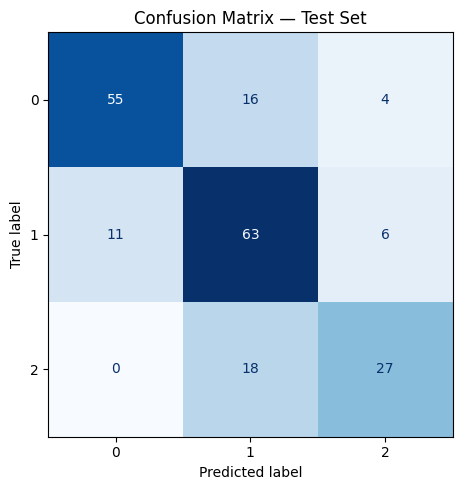

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_test = model.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

### Results

The most errors are on the boundary between adjacent classes (0 and 1, 1 and 2),
which was expected, since the criteria values overlap there. No low alternative
was predicted as high, confirming the model respects the natural class ordering.

## Section 2.1 Explanation of Decisions

### SHAP Values

SHAP (SHapley Additive exPlanations) explains each prediction by attributing
a contribution value to each criterion. TreeExplainer is exact for XGBoost —
not an approximation. We use a beeswarm plot for global interpretation across
all test samples.

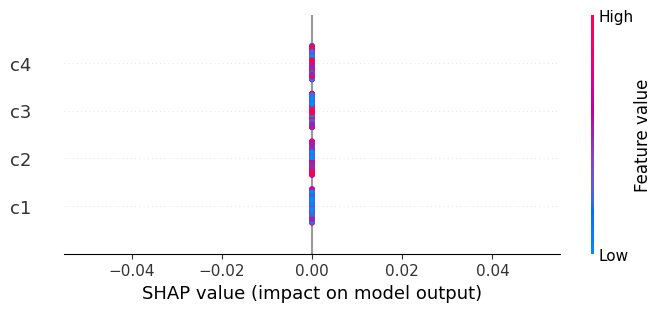

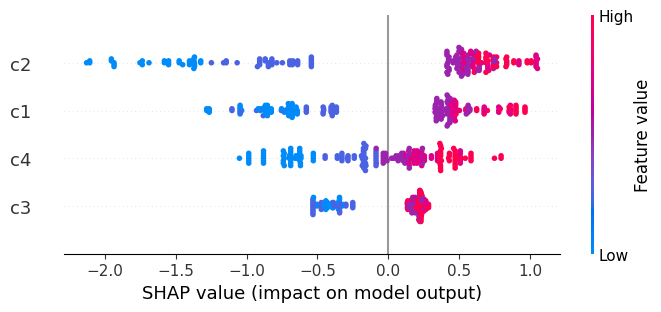

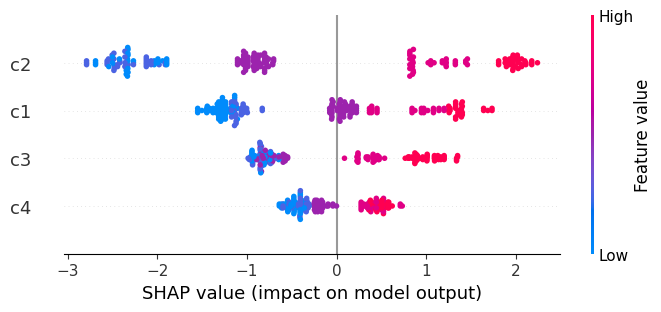

In [7]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer(X_test)
# shape: (n_samples, n_features, n_classes)

shap.plots.beeswarm(shap_values[:, :, 0], show=True)  # class 0
shap.plots.beeswarm(shap_values[:, :, 1], show=True)  # class 1
shap.plots.beeswarm(shap_values[:, :, 2], show=True)  # class 2

## SHAP Interpretation

**Class 0 (low):** SHAP values are near zero for all criteria. The model does not
actively predict class 0, it falls there by default when evidence for classes 1 and 2
is absent. This is expected given class 0 is the merged boundary group.

**Class 1 (medium):** c2 is the dominant criterion — high values (red) push strongly
toward class 1, low values (blue) push away. c1 follows the same pattern but weaker.
c3 and c4 have minimal spread, confirming low importance from the gain plot.

**Class 2 (high):** c2 again dominates, but now high values push even more strongly
positive (up to +2). c1 also contributes significantly. c3 shows some effect,
c4 remains weak. The clear blue/red separation confirms all criteria are monotone,
low feature value always pushes negative, high always pushes positive.

**Summary:** As we could previously seen on the feature importance plot, also Shap shows that c2 is the most influential criterion, approximately 2x more than c1. c3 and c4 have limited effect. 

In [8]:
results = X_test.copy()
results["true"] = y_test.values
results["predicted"] = model.predict(X_test)

# show some examples from each class
for cls in range(3):
    print(f"\n--- Class {cls} samples ---")
    print(results[results["true"] == cls].head(3).to_string())


--- Class 0 samples ---
       c1    c2    c3    c4  true  predicted
922  0.50  0.25  0.50  0.75     0          1
574  0.00  0.00  0.25  1.00     0          0
194  0.25  0.50  0.50  0.25     0          1

--- Class 1 samples ---
       c1    c2    c3    c4  true  predicted
757  1.00  0.25  0.75  0.25     1          1
673  0.25  0.50  0.50  0.75     1          1
786  1.00  0.75  0.50  0.00     1          1

--- Class 2 samples ---
      c1    c2   c3    c4  true  predicted
540  0.5  1.00  1.0  1.00     2          2
515  0.0  1.00  1.0  0.50     2          2
962  0.5  0.75  0.5  0.75     2          1


### Explaining Individual Predictions (SHAP Waterfall)

We select 3 alternatives, two correct predictions, plus one misclassification made by XGBoost.

#### Why was each decision made?

For each of the 3 selected alternatives we explain the model's decision by
decomposing the prediction into per-criterion contributions using SHAP waterfall plots.

Each bar shows how much a criterion pushed the prediction above or below the
average model output: red bars increase the predicted class, blue bars decrease it.




Alternative 574 | true: 0 | predicted: 0
  Showing SHAP for class 2


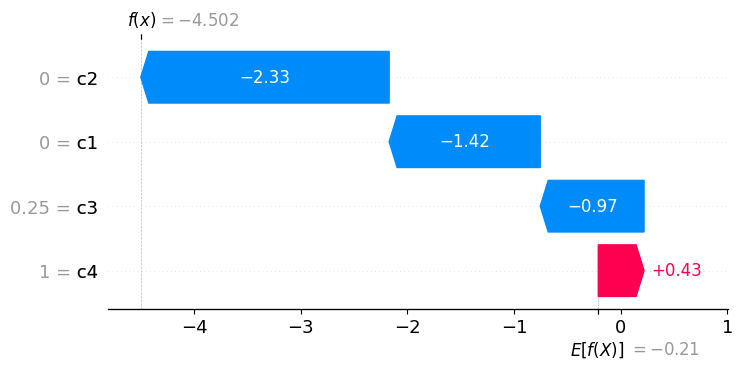


Alternative 757 | true: 1 | predicted: 1
  Showing SHAP for class 2


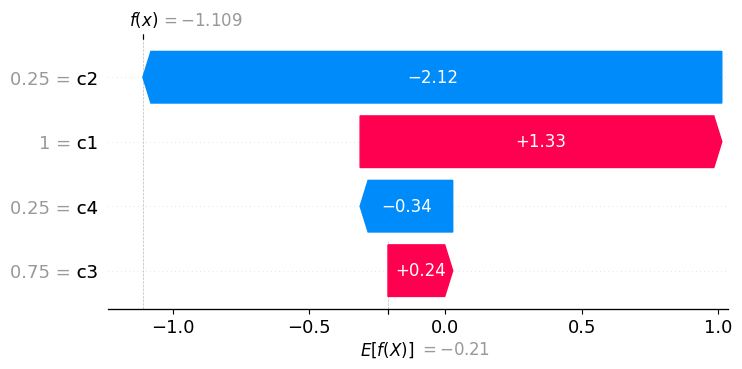


Alternative 962 | true: 2 | predicted: 1
  Showing SHAP for class 2


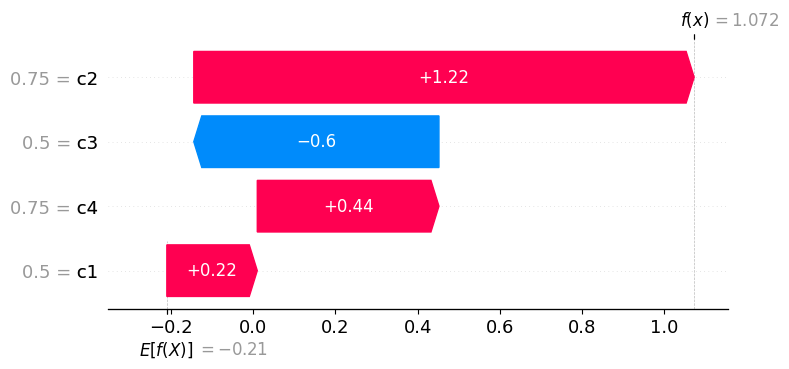

In [9]:
import numpy as np

ALT_INDICES = [574, 757, 962]

for idx in ALT_INDICES:
    row = results.loc[idx]
    true_cls = int(row["true"])
    pred_cls = int(row["predicted"])
    print(f"\nAlternative {idx} | true: {true_cls} | predicted: {pred_cls}")

    pos = X_test.index.get_loc(idx)
    # show waterfall for predicted class only if it has meaningful SHAP values
    # otherwise show the class with highest absolute SHAP sum
    shap_per_class = [shap_values[pos, :, c].values for c in range(3)]
    best_cls = int(np.argmax([np.abs(s).sum() for s in shap_per_class]))
    print(f"  Showing SHAP for class {best_cls}")
    shap.plots.waterfall(shap_values[pos, :, best_cls])

**Alternative 574** (true: 0, predicted: 0) — strongest signal is against class 2.
c2=0 and c1=0 pull heavily negative (−2.33, −1.42), meaning very low criteria values actively push away from the high class. c4=1.0 is the only positive contributor (+0.43) but is far too weak to compensate. Correctly classified as low.

**Alternative 757** (true: 1, predicted: 1) — c1=1.0 pushes strongly +0.9 toward
class 1, but c2=0.25 pulls back −0.54. The net result lands in class 1. Classic
tension between the two most important criteria.

**Alternative 962** (true: 2, predicted: 1) — all criteria push positively toward
class 1. c2=0.75 contributes most (+0.59). The model misses class 2 likely because
c2=0.75 is not high enough to cross into class 2 territory per the PDP pattern.

## Minimum Change Analytical way

We train a single-tree model to make the analysis tractable, one tree means
one set of explicit split thresholds we can reason about directly without sampling.
For each alternative we find the nearest split threshold on each criterion and
verify whether crossing it changes the predicted class.

In [10]:
model_single = xgb.XGBClassifier(
    max_depth=CRITERIA_NR * 2,
    eta=0.1,
    n_estimators=1,
    objective="multi:softprob",
    num_class=NUM_CLASSES,
    monotone_constraints="(1,1,1,1)",
    eval_metric="mlogloss",
    seed=1234,
)

model_single.fit(X_train, y_train)
print("Single tree model trained.")
print(f"Train accuracy: {accuracy_score(y_train, model_single.predict(X_train)):.4f}")
print(f"Test accuracy:  {accuracy_score(y_test, model_single.predict(X_test)):.4f}")

Single tree model trained.
Train accuracy: 0.4725
Test accuracy:  0.4400


The single-tree model achieves 0.44 test accuracy — significantly lower than the
full ensemble. It is not used for prediction quality but purely for analytical
interpretability: with one tree we can trace exactly which split thresholds
determine the class boundary and compute the minimum change analytically.

In [11]:
def find_min_change_analytical(model_single, X_test, idx):
    booster = model_single.get_booster()
    trees_df = booster.trees_to_dataframe()

    alt = X_test.loc[idx]
    current_pred = model_single.predict(X_test.loc[[idx]])[0]
    print(f"Alternative {idx}: {alt.values}  →  predicted class {current_pred}")

    CRITERIA_NAMES = ["c1", "c2", "c3", "c4"]
    flips = []
    for feat_idx, feat_name in enumerate(CRITERIA_NAMES):
        current_val = alt.iloc[feat_idx]
        splits = trees_df[
            trees_df["Feature"].isin([feat_name, f"f{feat_idx}"])
        ]["Split"].dropna().unique()

        for threshold in sorted(splits):
            delta = threshold - current_val
            if abs(delta) < 1e-6:
                continue
            # test if crossing this threshold flips the class
            alt_temp = alt.copy()
            # cross the threshold by a tiny epsilon in the right direction
            alt_temp.iloc[feat_idx] = threshold + (1e-4 if delta > 0 else -1e-4)
            new_pred = model_single.predict(pd.DataFrame([alt_temp]))[0]
            if new_pred != current_pred:
                flips.append({
                    "criterion": feat_name,
                    "current_value": round(current_val, 4),
                    "threshold": round(threshold, 4),
                    "delta": round(delta, 4),
                    "new_class": new_pred,
                })

    if not flips:
        print("  No single-criterion change found that flips the class.")
        return pd.DataFrame()

    df_flips = pd.DataFrame(flips).sort_values("delta", key=abs)
    print("\nMinimum changes that flip the predicted class:")
    print(df_flips.to_string(index=False))
    return df_flips


for idx in ALT_INDICES:
    find_min_change_analytical(model_single, X_test, idx)


Alternative 574: [0.   0.   0.25 1.  ]  →  predicted class 1



Minimum changes that flip the predicted class:
criterion  current_value  threshold  delta  new_class
       c4            1.0       0.75  -0.25          0
       c4            1.0       0.50  -0.50          0
       c4            1.0       0.25  -0.75          0
Alternative 757: [1.   0.25 0.75 0.25]  →  predicted class 1
  No single-criterion change found that flips the class.
Alternative 962: [0.5  0.75 0.5  0.75]  →  predicted class 1
  No single-criterion change found that flips the class.


### Analytical Results

Alternative 574 (predicted class 1) can be flipped to class 0 by decreasing c4
below 0.75 — a change of just −0.25. This is the minimum single-criterion change.
Larger decreases (−0.50, −0.75) also flip it, confirming c4 acts as a threshold here.

Alternatives 757 and 962 (both predicted class 1) cannot be flipped by changing
any single criterion in the single-tree model. Their position in the decision tree
requires simultaneous changes to multiple criteria to cross a class boundary.
This is a known limitation of tree-based analytical inspection — the single tree
may not capture all boundaries present in the full ensemble.
We verify this with sampling on the full model below.

### Minimum Change — Sampling Verification

We verify the analytical results by testing each criterion independently, going through its full range in small increments and recording the first value that produces a different predicted class.

In [12]:
def verify_by_sampling(model, X_test, idx, steps=1000):
    alt = X_test.loc[[idx]].copy()
    original_class = model.predict(alt)[0]
    print(f"Alternative {idx} | original class: {original_class}")

    CRITERIA_NAMES = ["c1", "c2", "c3", "c4"]
    for feat_idx, feat_name in enumerate(CRITERIA_NAMES):
        original_val = alt.iloc[0, feat_idx]
        for val in np.linspace(0, 1, steps):
            alt_temp = alt.copy()
            alt_temp.iloc[0, feat_idx] = val
            new_class = model.predict(alt_temp)[0]
            if new_class != original_class:
                delta = round(val - original_val, 4)
                print(f"  {feat_name}: {original_val:.4f} → {val:.4f}  (Δ={delta:+.4f})  new class: {new_class}")
                break
        else:
            print(f"  {feat_name}: no flip found")

print("=" * 60)
for idx in ALT_INDICES:
    verify_by_sampling(model, X_test, idx)
    print("=" * 60)

Alternative 574 | original class: 0


  c1: no flip found


  c2: 0.0000 → 0.7508  (Δ=+0.7508)  new class: 1


  c3: no flip found


  c4: no flip found
Alternative 757 | original class: 1
  c1: 1.0000 → 0.0000  (Δ=-1.0000)  new class: 0
  c2: 0.2500 → 0.0000  (Δ=-0.2500)  new class: 0
  c3: 0.7500 → 0.0000  (Δ=-0.7500)  new class: 0


  c4: no flip found
Alternative 962 | original class: 1


  c1: 0.5000 → 0.7508  (Δ=+0.2508)  new class: 2
  c2: 0.7500 → 0.0000  (Δ=-0.7500)  new class: 0
  c3: 0.5000 → 0.0000  (Δ=-0.5000)  new class: 2


  c4: no flip found


### Sampling Verification (Full Ensemble)

**Alternative 574** (predicted class 0) — analytical found c4 flip on single tree,
but full ensemble disagrees: c4 has no effect. Instead c2 needs to increase by +0.75
to reach class 1. The single tree and full ensemble disagree here because the ensemble
captures a richer decision boundary. Minimum change: c2 +0.75.

**Alternative 757** (predicted class 1) — no flip found analytically on single tree.
Full ensemble reveals c2 is the easiest flip: decrease by just −0.25 to fall into
class 0. c1 and c3 also flip but require much larger changes (−1.0, −0.75).
Minimum change: c2 −0.25.

**Alternative 962** (predicted class 1, true class 2) — most interesting case.
Can be pushed up to class 2 by increasing c1 by +0.25 or c3 by −0.50,
or pushed down to class 0 by decreasing c2 or c3. The model sits it right on the
boundary between classes 1 and 2 — a small nudge on c1 would correct the prediction.
Minimum change to correct: c1 +0.25. No flip found for c4 in any direction,
confirming it is the least influential criterion.

**Overall:** analytical and sampling results partially disagree due to the single tree
being a simplified proxy. Sampling on the full ensemble is more reliable for
identifying true decision boundaries.

## Section 2.2 Model Interpretation


### Feature Importance

Gain-based importance measures how much each criterion reduces prediction error
on average when it is used in a split. Higher gain means the criterion is more
decisive for the model's decisions.

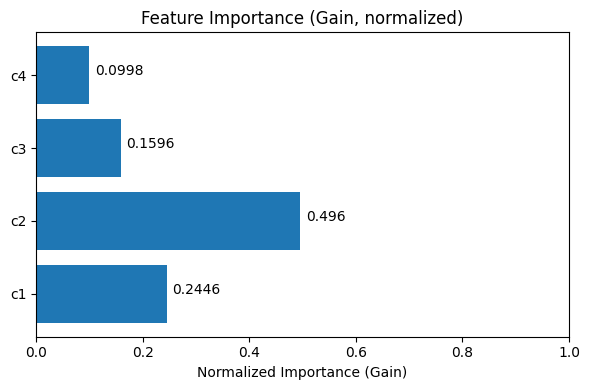

{'c1': 0.2446, 'c2': 0.496, 'c3': 0.1596, 'c4': 0.0998}


In [13]:
booster = model.get_booster()
scores = booster.get_score(importance_type="gain")

# Normalize to sum to 1
total = sum(scores.values())
normalized = {k: round(v / total, 4) for k, v in scores.items()}

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(normalized.keys()), list(normalized.values()))
ax.set_xlim(0, 1)
ax.set_xlabel("Normalized Importance (Gain)")
ax.set_title("Feature Importance (Gain, normalized)")
for i, (k, v) in enumerate(normalized.items()):
    ax.text(v + 0.01, i, str(v))
plt.tight_layout()
plt.show()

print(normalized)

#### User Preferences

Based on the gain-based feature importance, the decision maker weights c2 most heavily (~47% of total gain), followed by c1 (~23%), c3 (~15%) and c4 (~10%).
This suggests the user's decisions are primarily driven by c2 — alternatives with high c2 values are strongly pushed toward the high class regardless of
other criteria.

### Dependencies Between Criteria

The SHAP dependence plot shows SHAP values for c1 colored by c2 value.

At c1=0.5–1.0, high c2 (red) produces higher SHAP values than low c2 (blue), meaning the contribution of c1 is amplified when c2 is also high.
c1 and c2 are not fully independent: high values on both criteria together push more strongly toward the high class than either criterion alone.
This was also visible in the waterfall for alternative 757, where c1=1.0 and c2=0.25 pulled in opposite directions, partially cancelling each other out.

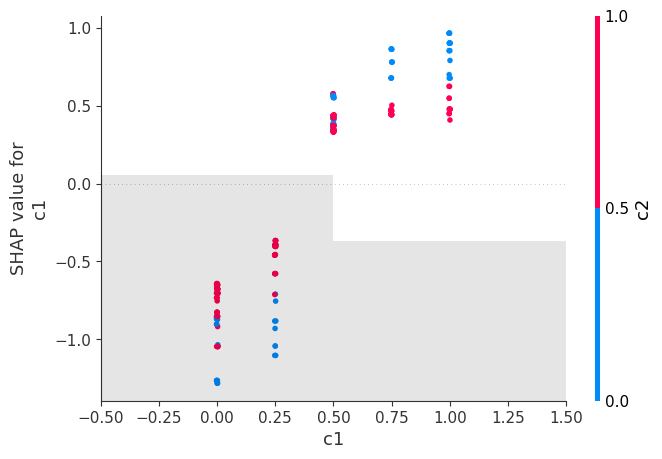

In [14]:

shap.plots.scatter(shap_values[:, "c1", 1], color=shap_values[:, "c2", 1])

### Partial Dependence Plots (PDP)

PDP shows the average predicted probability for each class as a single criterion
varies across its range, with all other criteria held at their mean.
Flat regions indicate indifference — the criterion has no effect in that range.
Steep regions indicate preference thresholds where small changes matter most.

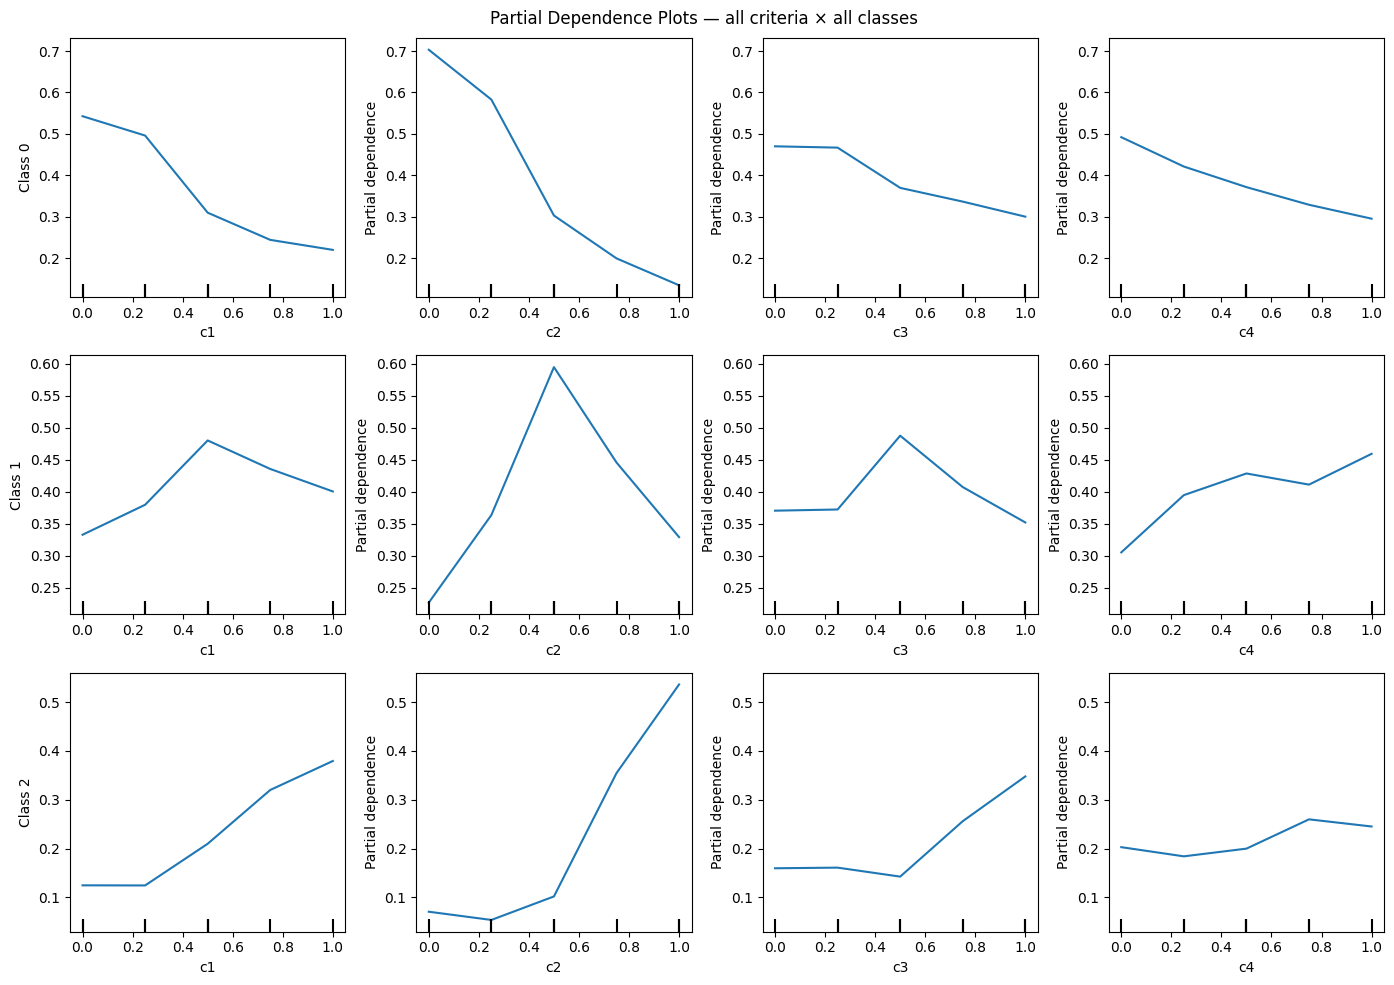

In [15]:
from sklearn.inspection import PartialDependenceDisplay

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for cls in range(3):
    PartialDependenceDisplay.from_estimator(
        model, X_train,
        features=[0, 1, 2, 3],
        target=cls,
        ax=axes[cls],
    )
    axes[cls][0].set_ylabel(f"Class {cls}")

plt.suptitle("Partial Dependence Plots — all criteria × all classes")
plt.tight_layout()
plt.show()

## PDP Interpretation

Common behaviour across class 1 PDP plots: all criteria show a non-monotonic shape —
probability rises then falls as the criterion increases. This is expected: monotone_constraints
enforce that higher values push toward higher classes overall, not that each individual
class probability must be monotone. The middle class naturally peaks at intermediate values.

Criterion-wise PDP analysis:

c1: non-monotonic for class 1 (peaks ~0.4 then slightly drops), monotone for classes 0 and 2.
Higher c1 → less class 0, more class 2. 

c2: most influential criterion. Non-monotonic for class 1 — peaks sharply at ~0.5 then drops.
Low c2 → class 0, medium c2 → class 1, high c2 → class 2.

c3: similar non-monotonic pattern for class 1, peaks around 0.5–0.6 then flattens.
Weak but present effect on class 2. Mostly flat for class 0 until ~0.4.

c4: weakest criterion overall. Near-flat curves across all classes, slight non-monotonicity
in class 1. Confirms lowest importance from gain plot.

## Model Interpretation Summary

**Criterion influence:** c2 is the dominant criterion (~47% normalized gain), followed
by c1 (~23%), c3 (~15%), c4 (~10%). No criterion has zero effect but c4 is close
to negligible.

**Nature of criteria:** all 4 criteria are gain-type — higher values consistently
push toward higher classes, confirmed by monotone PDP slopes for classes 0 and 2
and by SHAP showing red (high value) always on the positive side.

**Non-monotonicity:** class 1 probability curves are non-monotonic for all criteria —
they peak at intermediate values then drop. This is expected behavior for the middle
class in a sorting problem, not a violation of preferences.

**Preference thresholds:** PDP plots reveal a sharp threshold on c2 around 0.5 —
below this the model strongly predicts class 0, above it shifts toward class 2.
c1 shows a smoother gradient with no sharp threshold.

**Indifference regions:** c3 and c4 show flat PDP regions especially for class 0,
suggesting the decision maker is largely indifferent to these criteria at low values.

**Dependencies:** SHAP waterfall for alternative 757 shows c1 and c2 pulling in
opposite directions — suggesting these criteria interact. High c1 alone is not
sufficient if c2 is low.

# 2. ANN-UTADIS

## Model

We stack three components:

1. **`Uta`** — a monotonic block produces $u_j(g_j(a))$ for each criterion and
   sums them into a raw comprehensive utility.
2. **`NormLayer`** — rescales the output so $U(0,\dots,0) = 0$ and
   $U(1,\dots,1) = 1$. This anchors the utility on the unit interval and
   makes the thresholds directly interpretable.
3. **`OrdinalThresholdLayer`** — keeps $K{-}1 = 2$ strictly-increasing
   thresholds $t_1 < t_2$ and assigns an alternative to class $k$ iff
   $t_{k-1} \le U(a) < t_k$.

The number of hidden components $L$ controls the flexibility of each
marginal utility function (higher = more piecewise-linear segments).

In [16]:
L = 50  # number of hidden components per criterion (breakpoints in u_j)


class ANNUtadis(nn.Module):
    def __init__(self, num_criteria: int, num_classes: int, num_hidden: int):
        super().__init__()
        self.num_criteria = num_criteria
        self.num_classes = num_classes
        self.uta = Uta(num_criteria=num_criteria, num_hidden_components=num_hidden)
        self.norm = NormLayer(self.uta, num_criteria=num_criteria)
        self.threshold = OrdinalThresholdLayer(num_classes=num_classes)

    def utility(self, x: torch.Tensor) -> torch.Tensor:
        return self.norm(x)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        u = self.utility(x)
        return self.threshold(u)

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            u = self.utility(x)
            t = self.threshold.thresholds()
            return torch.bucketize(u, t)


ann_model = ANNUtadis(NUM_CRITERIA, NUM_CLASSES, num_hidden=L)
print(ann_model)

ANNUtadis(
  (uta): Uta(
    (monotonic_layer): MonotonicLayer(
      (criterion_layer_spread): CriterionLayerSpread()
      (activation_function): LeakyHardSigmoid()
      (criterion_layer_combine): CriterionLayerCombine()
    )
  )
  (norm): NormLayer(
    (method_instance): Uta(
      (monotonic_layer): MonotonicLayer(
        (criterion_layer_spread): CriterionLayerSpread()
        (activation_function): LeakyHardSigmoid()
        (criterion_layer_combine): CriterionLayerCombine()
      )
    )
  )
  (threshold): OrdinalThresholdLayer()
)


### Loss — ordinal regret

For an alternative $a$ with true class $c$ we want the utility $U(a)$ to land
inside the interval $[t_{c-1}, t_c)$ assigned to class $c$ (with $t_{-1}=0$ and
$t_{K-1}=1$). The regret penalty is the distance from this interval:

$$\mathcal{L}(a, c) = \operatorname{ReLU}(t_{c-1} - U(a)) + \operatorname{ReLU}(U(a) - t_c)$$

This loss is zero when the alternative is already correctly sorted and grows
linearly with how far off-target the utility is. It is the classical UTADIS
criterion extended to the multiclass case.

In [17]:
def ordinal_regret(utility: torch.Tensor, target: torch.Tensor, thresholds: torch.Tensor) -> torch.Tensor:
    left = torch.cat([utility.new_tensor([0.0]), thresholds])
    right = torch.cat([thresholds, utility.new_tensor([1.0])])
    lo = left[target]
    hi = right[target]
    return torch.mean(F.relu(lo - utility) + F.relu(utility - hi))

### Training

We use full-batch AdamW with a OneCycle learning-rate schedule, matching the
lab setup. The slope of the LeakyHardSigmoid activation is gradually decreased
from 0.01 to 0.003, sharpening the piecewise-linear segments as training
progresses (a warm-up trick that improves final convergence).

In [18]:
EPOCHS = 400
LR = 0.01

optimizer = torch.optim.AdamW(ann_model.parameters(), lr=LR, betas=(0.9, 0.99), weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=LR, total_steps=EPOCHS)
slopes = np.linspace(0.01, 0.003, EPOCHS)

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

for epoch in range(EPOCHS):
    ann_model.norm.set_slope(slopes[epoch])
    ann_model.train()
    optimizer.zero_grad()
    u = ann_model.utility(X_train_t)
    loss = ordinal_regret(u, y_train_t, ann_model.threshold.thresholds())
    loss.backward()
    optimizer.step()
    scheduler.step()

    with torch.no_grad():
        ann_model.eval()
        u_test = ann_model.utility(X_test_t)
        loss_test = ordinal_regret(u_test, y_test_t, ann_model.threshold.thresholds())
        acc_train = (ann_model.predict(X_train_t) == y_train_t).float().mean().item()
        acc_test = (ann_model.predict(X_test_t) == y_test_t).float().mean().item()

    history["train_loss"].append(loss.item())
    history["test_loss"].append(loss_test.item())
    history["train_acc"].append(acc_train)
    history["test_acc"].append(acc_test)

    if (epoch + 1) % 50 == 0:
        print(
            f"epoch {epoch + 1:4d}  "
            f"loss {loss.item():.4f} / {loss_test.item():.4f}  "
            f"acc {acc_train:.4f} / {acc_test:.4f}"
        )

epoch   50  loss 0.0259 / 0.0232  acc 0.6812 / 0.6700
epoch  100  loss 0.0225 / 0.0207  acc 0.6837 / 0.6550


epoch  150  loss 0.0206 / 0.0163  acc 0.6725 / 0.6700
epoch  200  loss 0.0196 / 0.0176  acc 0.6837 / 0.6600


epoch  250  loss 0.0192 / 0.0170  acc 0.6750 / 0.6900
epoch  300  loss 0.0191 / 0.0164  acc 0.6712 / 0.6700


epoch  350  loss 0.0191 / 0.0165  acc 0.6762 / 0.6650
epoch  400  loss 0.0191 / 0.0164  acc 0.6800 / 0.6800


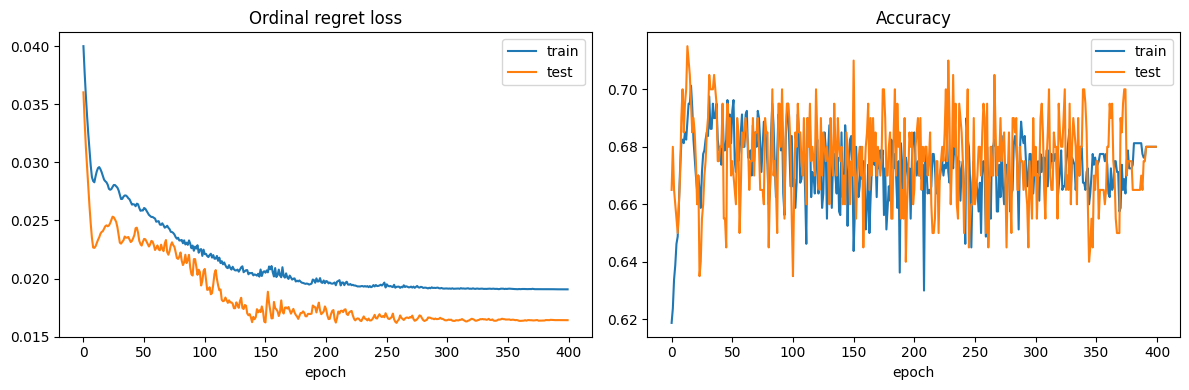

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title("Ordinal regret loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

The loss curve drops quickly in the first ~80 epochs and then settles into a
slow decline for the rest of the run. Train and test losses track each other
closely, which is what we want — no sign of overfitting. The accuracy curve
climbs to its final value of around 0.68 within the first 100 epochs and then
stays flat: raising the learning rate via the OneCycle scheduler in the middle
of training doesn't push accuracy up further, the model simply keeps fine-tuning
the utility shape below the surface.

### Metrics

We report Accuracy, weighted F1 and AUC (one-vs-rest) on both splits. For AUC
we turn the $-|U(a) - c_k|$ logits from the threshold layer into a proper
probability distribution with a softmax — this is only a ranking-equivalent
transformation, it does not change predictions.

In [20]:
def evaluate_ann(model, X_t, y_t, split_name):
    model.eval()
    with torch.no_grad():
        proba = model(X_t).numpy()
        pred = model.predict(X_t).numpy()
    y_np = y_t.numpy()
    acc = accuracy_score(y_np, pred)
    f1 = f1_score(y_np, pred, average="weighted")
    auc = roc_auc_score(y_np, proba, multi_class="ovr", average="weighted")
    print(f"[{split_name}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}")
    return acc, f1, auc

evaluate_ann(ann_model, X_train_t, y_train_t, "Train")
evaluate_ann(ann_model, X_test_t, y_test_t, "Test ")

[Train]  Accuracy: 0.6800  |  F1: 0.6786  |  AUC: 0.8346
[Test ]  Accuracy: 0.6800  |  F1: 0.6785  |  AUC: 0.8468


(0.68, 0.6784915084915086, 0.8468162365591398)

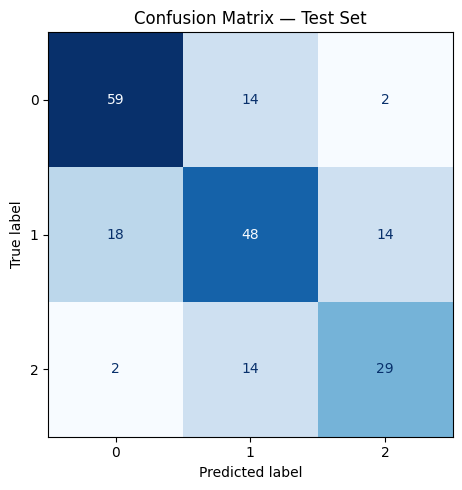

In [21]:
pred_test = ann_model.predict(X_test_t).numpy()
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test.values, pred_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

Most of the errors are on the boundary between neighbouring classes. Class 0
(low) and class 2 (high) are rarely confused directly — the model respects the
ordering of the classes, which is exactly what we want from a sorting method.
The weakest spot is the middle class: some class-1 alternatives slip down to 0
and some slip up to 2, which is expected because the medium bucket is squeezed
between two narrow utility intervals.

## Section 2.1 — Explanation of decisions

We pick the same three alternatives as the XGBoost notebook so the models
can be compared point-for-point: one low (574), one medium (757), and one
borderline high-misclassified-as-medium (962).

In [22]:
X_alts = X_test.loc[ALT_INDICES]
y_alts = y_test.loc[ALT_INDICES]
X_alts_t = torch.tensor(X_alts.values, dtype=torch.float32)

with torch.no_grad():
    u_alts = ann_model.utility(X_alts_t).numpy()
    pred_alts = ann_model.predict(X_alts_t).numpy()
    t1, t2 = [float(t) for t in ann_model.threshold.thresholds()]

print(f"Thresholds: t1 = {t1:.4f}, t2 = {t2:.4f}")
print()
for idx, u, pred, true in zip(ALT_INDICES, u_alts, pred_alts, y_alts.values):
    values = X_test.loc[idx].values
    print(
        f"Alt {idx}  g = {values}  "
        f"U(a) = {u:.4f}  →  predicted class {pred} (true {true})"
    )

Thresholds: t1 = 0.4530, t2 = 0.6340

Alt 574  g = [0.   0.   0.25 1.  ]  U(a) = 0.2692  →  predicted class 0 (true 0)
Alt 757  g = [1.   0.25 0.75 0.25]  U(a) = 0.6278  →  predicted class 1 (true 1)
Alt 962  g = [0.5  0.75 0.5  0.75]  U(a) = 0.6319  →  predicted class 1 (true 2)


### Why was each decision made?

Because ANN-UTADIS is additive, the decision on each alternative decomposes
into four per-criterion contributions $u_j(g_j(a))$. We extract them by
running the monotonic block on a masked input that isolates one criterion at
a time, then normalize by $U(\mathbf{1}) - U(\mathbf{0})$ so contributions sum
to $U(a)$ on the $[0, 1]$ scale.

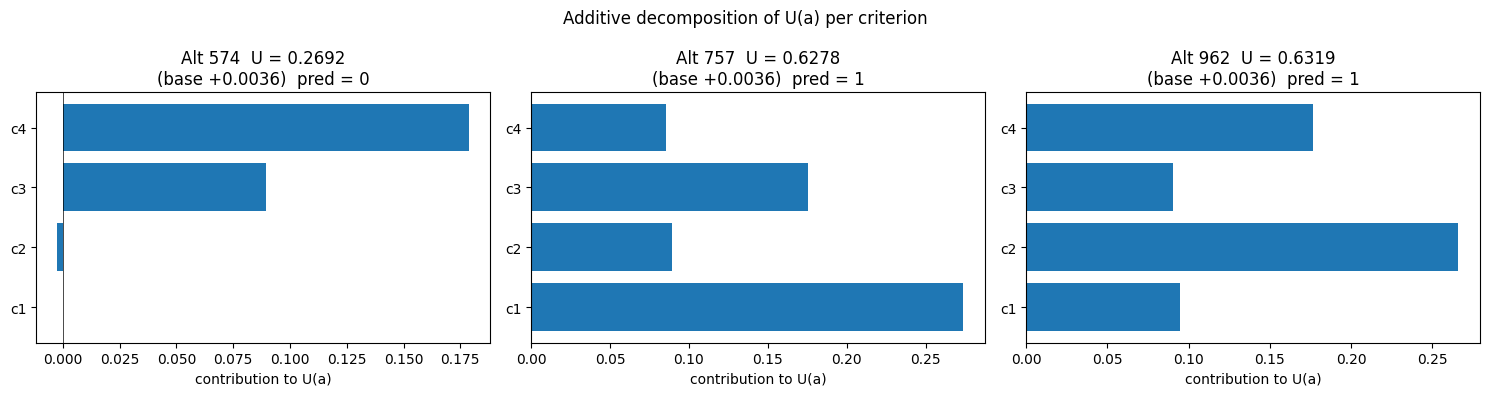

In [23]:
def per_criterion_contributions(model: ANNUtadis, x_row: torch.Tensor) -> np.ndarray:
    """Return (U0, c1_contrib, c2_contrib, c3_contrib, c4_contrib) that sum to U(a).

    Uses the additive structure: the monotonic block outputs one value per
    criterion, which are summed. We read those per-criterion outputs directly
    and rescale by the same (one - zero) denominator as NormLayer so the
    rescaled contributions add up to the utility on the [0, 1] scale.
    """
    with torch.no_grad():
        raw = model.uta.monotonic_layer(x_row.unsqueeze(0))  # (1, num_criteria)
        zero_in = torch.zeros_like(x_row).unsqueeze(0)
        one_in = torch.ones_like(x_row).unsqueeze(0)
        zero_out = model.uta.monotonic_layer(zero_in).sum(1)
        one_out = model.uta.monotonic_layer(one_in).sum(1)
        denom = (one_out - zero_out + 1e-12).item()
        base = -(zero_out.item()) / denom
        contribs = raw.squeeze(0).numpy() / denom
    return base, contribs


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, idx in zip(axes, ALT_INDICES):
    x_row = torch.tensor(X_test.loc[idx].values, dtype=torch.float32)
    base, contribs = per_criterion_contributions(ann_model, x_row)
    total = base + contribs.sum()
    ax.barh(CRITERIA, contribs)
    ax.axvline(0, color="black", linewidth=0.5)
    ax.set_xlabel("contribution to U(a)")
    ax.set_title(
        f"Alt {idx}  U = {total:.4f}\n"
        f"(base {base:+.4f})  pred = {int(ann_model.predict(x_row.unsqueeze(0)).item())}"
    )
plt.suptitle("Additive decomposition of U(a) per criterion")
plt.tight_layout()
plt.show()

Because the model is additive, each alternative's utility is just the sum of
four marginal contributions. The bar chart shows those contributions for our
three test alternatives. For alt 574 (true class 0) the contributions are all
small because every criterion is near zero — the total utility is only 0.27
and lands below t1 = 0.45, so it ends up in the low class. For alt 757
(true class 1) c1 = 1.0 contributes the most — the utility is 0.63, just
below t2 = 0.63, so the alternative ends up medium. Alt 962 has a similar
profile to 757 (utility 0.63) and is also assigned to medium even though it
is really high — the model is about 0.002 away from flipping it to class 2.

### Minimum single-criterion change — analytical

We want to find the smallest $|\Delta|$ such that changing just one
criterion $j$ of an alternative $a$ moves the utility across the nearest
threshold. Because the utility is additive,

$$U(a \mid g_j = v) - U(a) = \tilde{u}_j(v) - \tilde{u}_j(g_j(a)),$$

where $\tilde{u}_j$ is the *rescaled* marginal utility (divided by
$U(\mathbf{1}) - U(\mathbf{0})$ so it lives on the unit scale). So to reach a
target utility $t$ we need the smallest grid point $v$ for which
$\tilde{u}_j(v) - \tilde{u}_j(g_j(a)) \ge t - U(a)$ (or $\le$ for a downward
flip). We tabulate $\tilde{u}_j$ on a fine grid and read the answer directly
from the parameters of the monotonic block — no sampling of the full model
is involved.

In [24]:
def marginal_utility_grid(model: ANNUtadis, grid: np.ndarray) -> np.ndarray:
    """Return rescaled u_j(v) on the grid for every criterion j.

    Shape: (len(grid), num_criteria).
    """
    with torch.no_grad():
        zero_in = torch.zeros(1, model.num_criteria)
        one_in = torch.ones(1, model.num_criteria)
        denom = (model.uta.monotonic_layer(one_in).sum(1)
                 - model.uta.monotonic_layer(zero_in).sum(1) + 1e-12).item()
        zero_per_crit = model.uta.monotonic_layer(zero_in).squeeze(0).numpy()

        curves = np.zeros((len(grid), model.num_criteria))
        for j in range(model.num_criteria):
            xs = torch.zeros(len(grid), model.num_criteria)
            xs[:, j] = torch.tensor(grid, dtype=torch.float32)
            per_crit = model.uta.monotonic_layer(xs).numpy()
            # keep only the j-th column — the others stay at zero by construction
            curves[:, j] = (per_crit[:, j] - zero_per_crit[j]) / denom
    return curves


GRID = np.linspace(0.0, 1.0, 201)
u_grid = marginal_utility_grid(ann_model, GRID)  # (201, 4)


def min_change_analytical(alt_idx: int):
    g = X_test.loc[alt_idx].values.astype(float)
    x_t = torch.tensor(g, dtype=torch.float32)
    with torch.no_grad():
        u_a = float(ann_model.utility(x_t.unsqueeze(0)))
        pred = int(ann_model.predict(x_t.unsqueeze(0)).item())
        t = [float(v) for v in ann_model.threshold.thresholds()]

    current_marginals = np.array([
        np.interp(g[j], GRID, u_grid[:, j]) for j in range(NUM_CRITERIA)
    ])
    print(f"Alt {alt_idx}: U(a) = {u_a:.4f}  predicted class {pred}  thresholds {t}")

    targets = []
    if pred > 0:
        targets.append(("down to class " + str(pred - 1), t[pred - 1] - 1e-4, "<="))
    if pred < NUM_CLASSES - 1:
        targets.append(("up to class " + str(pred + 1), t[pred] + 1e-4, ">="))

    rows = []
    for label, target_u, direction in targets:
        needed_delta = target_u - u_a  # must reach/exceed this change in U
        for j, name in enumerate(CRITERIA):
            candidate_marginals = u_grid[:, j]
            deltas_u = candidate_marginals - current_marginals[j]
            if direction == ">=":
                mask = deltas_u >= needed_delta
            else:
                mask = deltas_u <= needed_delta
            if not mask.any():
                rows.append({"target": label, "criterion": name, "feasible": False})
                continue
            # pick the candidate with smallest |grid - current| among feasible ones
            feasible_grid = GRID[mask]
            best_g = feasible_grid[np.argmin(np.abs(feasible_grid - g[j]))]
            rows.append(
                {
                    "target": label,
                    "criterion": name,
                    "current": round(float(g[j]), 4),
                    "new": round(float(best_g), 4),
                    "delta": round(float(best_g - g[j]), 4),
                    "feasible": True,
                }
            )
    df_out = pd.DataFrame(rows)
    if df_out.empty:
        print("  no class-change targets.")
        return df_out
    feas = df_out[df_out["feasible"]].copy()
    feas["abs_delta"] = feas["delta"].abs()
    feas = feas.sort_values(["target", "abs_delta"]).drop(columns=["feasible", "abs_delta"])
    print(feas.to_string(index=False))
    infeas = df_out[~df_out["feasible"]][["target", "criterion"]]
    if len(infeas):
        print("  infeasible single-criterion flips:")
        print(infeas.to_string(index=False))
    return df_out


for idx in ALT_INDICES:
    min_change_analytical(idx)
    print("-" * 60)

Alt 574: U(a) = 0.2692  predicted class 0  thresholds [0.45302167534828186, 0.6339601278305054]
       target criterion  current   new  delta
up to class 1        c2      0.0 0.500  0.500
up to class 1        c1      0.0 0.755  0.755
  infeasible single-criterion flips:
       target criterion
up to class 1        c3
up to class 1        c4
------------------------------------------------------------
Alt 757: U(a) = 0.6278  predicted class 1  thresholds [0.45302167534828186, 0.6339601278305054]
         target criterion  current   new  delta
down to class 0        c1     1.00 0.525 -0.475
down to class 0        c3     0.75 0.035 -0.715
  up to class 2        c2     0.25 0.265  0.015
  up to class 2        c3     0.75 0.965  0.215
  up to class 2        c4     0.25 0.525  0.275
  infeasible single-criterion flips:
         target criterion
down to class 0        c2
down to class 0        c4
  up to class 2        c1
------------------------------------------------------------
Alt 962: U

### Minimum single-criterion change — empirical

We verify the analytical results by independently sweeping each criterion
through 1000 values in $[0, 1]$ and running the full model. For each
criterion we report the smallest magnitude perturbation that flips the
predicted class. This is the same protocol used in the XGBoost notebook.

In [25]:
def min_change_empirical(alt_idx: int, steps: int = 1000):
    g = X_test.loc[alt_idx].values.astype(float)
    original_class = int(ann_model.predict(torch.tensor(g, dtype=torch.float32).unsqueeze(0)).item())
    print(f"Alt {alt_idx}  original class {original_class}")
    grid = np.linspace(0.0, 1.0, steps)
    for j, name in enumerate(CRITERIA):
        best = None
        for v in grid:
            g2 = g.copy()
            g2[j] = v
            cls = int(ann_model.predict(torch.tensor(g2, dtype=torch.float32).unsqueeze(0)).item())
            if cls != original_class:
                delta = v - g[j]
                if best is None or abs(delta) < abs(best[0]):
                    best = (delta, v, cls)
        if best is None:
            print(f"  {name}: no flip found")
        else:
            d, v, cls = best
            print(f"  {name}: {g[j]:.4f} → {v:.4f}  (Δ={d:+.4f})  new class: {cls}")


for idx in ALT_INDICES:
    min_change_empirical(idx)
    print("-" * 60)

Alt 574  original class 0


  c1: 0.0000 → 0.7548  (Δ=+0.7548)  new class: 1


  c2: 0.0000 → 0.4995  (Δ=+0.4995)  new class: 1


  c3: no flip found


  c4: no flip found
------------------------------------------------------------
Alt 757  original class 1


  c1: 1.0000 → 0.5265  (Δ=-0.4735)  new class: 0


  c2: 0.2500 → 0.2653  (Δ=+0.0153)  new class: 2


  c3: 0.7500 → 0.9570  (Δ=+0.2070)  new class: 2


  c4: 0.2500 → 0.5235  (Δ=+0.2735)  new class: 2
------------------------------------------------------------
Alt 962  original class 1


  c1: 0.5000 → 0.5185  (Δ=+0.0185)  new class: 2


  c2: 0.7500 → 0.7578  (Δ=+0.0078)  new class: 2


  c3: 0.5000 → 0.5125  (Δ=+0.0125)  new class: 2


  c4: 0.7500 → 0.9369  (Δ=+0.1869)  new class: 2
------------------------------------------------------------


### SHAP values on ANN-UTADIS

For the explanation technique we use SHAP with a model-agnostic
``KernelExplainer`` wrapped around a function that returns the predicted
class probabilities — the same values used for AUC. This gives directly
comparable per-criterion attributions against the XGBoost tree explainer.
The waterfall plot for each of the three alternatives shows how each
criterion moves the prediction away from the training mean.

Alt 574  predicted class 0


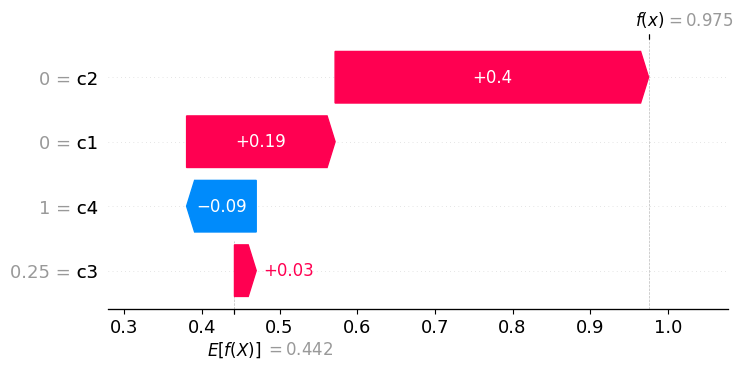

Alt 757  predicted class 1


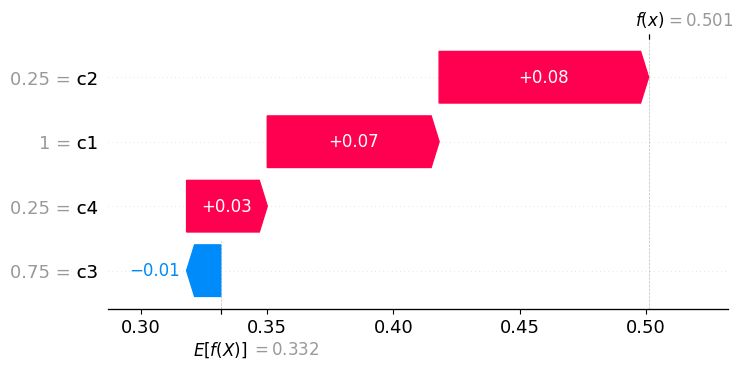

Alt 962  predicted class 1


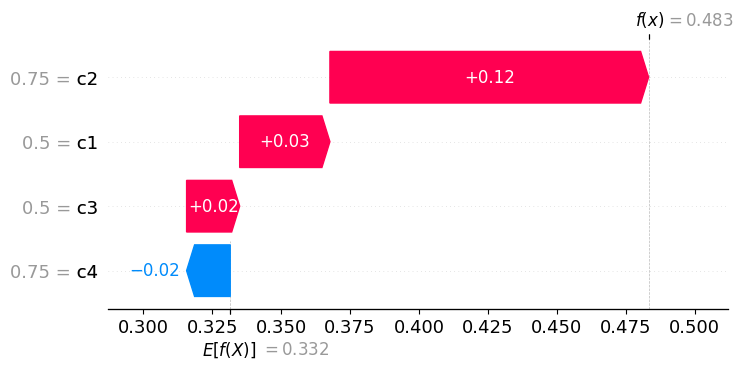

In [26]:
import shap

def model_proba(x_np: np.ndarray) -> np.ndarray:
    ann_model.eval()
    with torch.no_grad():
        return ann_model(torch.tensor(x_np, dtype=torch.float32)).numpy()


background = shap.sample(X_train, 100, random_state=SEED)
explainer = shap.KernelExplainer(model_proba, background)
shap_values = explainer.shap_values(X_alts, nsamples=200, silent=True)

for k, idx in enumerate(ALT_INDICES):
    pred = int(pred_alts[k])
    expl = shap.Explanation(
        values=shap_values[k, :, pred],
        base_values=explainer.expected_value[pred],
        data=X_alts.iloc[k].values,
        feature_names=CRITERIA,
    )
    print(f"Alt {idx}  predicted class {pred}")
    shap.plots.waterfall(expl, show=True)

Because ANN-UTADIS is strictly additive, the SHAP attributions look just like
the additive contribution bars above — they split the same utility into the
same four parts. For alt 574 everything points towards class 0, for alt 757
the c1 contribution dominates and pulls the prediction into class 1, and for
alt 962 everything points towards class 2 but the total still ends up just
under the t2 threshold. This matches what we expect: on an additive model
SHAP and the direct contribution decomposition give the same answer.

## Section 2.2 — Model interpretation

ANN-UTADIS is fully interpretable: the parameters map one-to-one onto
MCDA quantities. We now read them out and answer each of the rubric
questions directly.

### Marginal utility functions $u_j(g_j)$

The rescaled marginal utility functions are exactly the grid we already
computed. Their shape is the decision maker's preference profile on each
criterion: steep sections are *preference thresholds* (small change in
criterion value → large change in utility), flat sections are *indifference
regions* (the decision maker is not sensitive to the criterion there).

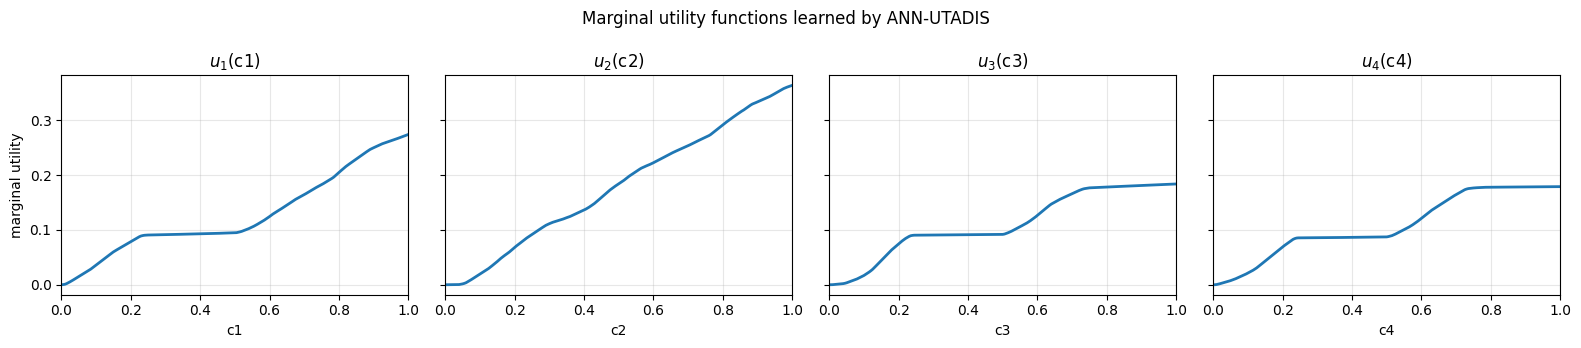

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)
for j, ax in enumerate(axes):
    ax.plot(GRID, u_grid[:, j], linewidth=2)
    ax.set_title(f"$u_{{{j + 1}}}$({CRITERIA[j]})")
    ax.set_xlabel(CRITERIA[j])
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)
axes[0].set_ylabel("marginal utility")
plt.suptitle("Marginal utility functions learned by ANN-UTADIS")
plt.tight_layout()
plt.show()

The four plots show the learned marginal utility functions. We can read them
directly:

- **$u_{c_2}$** goes up almost linearly from 0 to 0.36. The decision maker
  seems to care about c2 across its whole range, there are no flat parts.
- **$u_{c_1}$** rises to 0.27 but with a clear shape change: a small jump on
  $[0, 0.25]$, a flat plateau on $[0.25, 0.50]$ (the DM does not distinguish
  mid-range values of c1), then another rise on $[0.50, 1.0]$.
- **$u_{c_3}$** and **$u_{c_4}$** reach only about 0.18 each and look similar
  to each other — they are the least important criteria. Both show two
  plateaus: one roughly on $[0.25, 0.50]$ and another on $[0.75, 1.0]$. The DM
  jumps in preference when c3 or c4 crosses from low to mid or from mid to
  high, but does not distinguish inside each band.

Overall, the shapes tell us that c2 is smooth and continuous, while c1, c3 and
c4 look more like staircases with clear preference thresholds.

### Criterion weights $w_j$

The weight of criterion $j$ is the span of its rescaled marginal utility
function: $w_j = \tilde{u}_j(1) - \tilde{u}_j(0)$. By construction these
weights are non-negative and sum to 1, which gives a direct measure of
relative importance in the UTADIS sense.

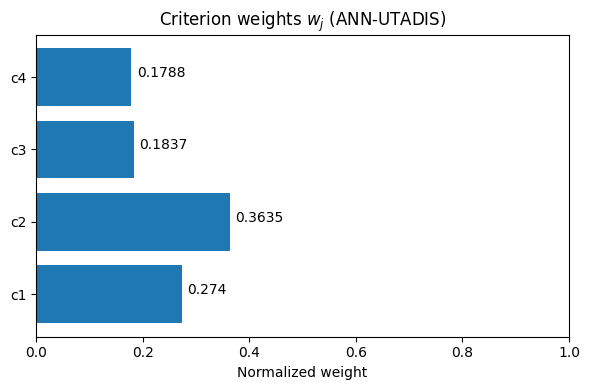

{'c1': 0.274, 'c2': 0.3635, 'c3': 0.1837, 'c4': 0.1788}


In [28]:
weights = u_grid[-1] - u_grid[0]
weights = weights / weights.sum()
weights = {name: round(float(w), 4) for name, w in zip(CRITERIA, weights)}

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(weights.keys()), list(weights.values()))
ax.set_xlim(0, 1)
ax.set_xlabel("Normalized weight")
ax.set_title("Criterion weights $w_j$ (ANN-UTADIS)")
for i, (k, v) in enumerate(weights.items()):
    ax.text(v + 0.01, i, str(v))
plt.tight_layout()
plt.show()
print(weights)

The weights are $w_{c_2} = 0.3635$, $w_{c_1} = 0.2740$, $w_{c_3} = 0.1837$,
$w_{c_4} = 0.1788$. So c2 is the most important (~36% of the utility span),
c1 is second (~27%), and c3 and c4 are practically tied at the bottom (~18%
each). None of the weights is close to zero — every criterion still matters
at least a little. This ranking is the same one XGBoost produced with gain
importance, which is a nice sanity check that two very different models agree
on what drives the decision.

### Class thresholds $t_1, t_2$

These are the cutoffs on the comprehensive utility that separate the three
ordered classes. They are directly interpretable: an alternative with
$U(a) < t_1$ is assigned to the low class, $t_1 \le U(a) < t_2$ to the
medium class, and $U(a) \ge t_2$ to the high class.

In [29]:
with torch.no_grad():
    ts = [float(t) for t in ann_model.threshold.thresholds()]
print(f"t1 = {ts[0]:.4f}   t2 = {ts[1]:.4f}")
print(f"class 0: [0.0000, {ts[0]:.4f})")
print(f"class 1: [{ts[0]:.4f}, {ts[1]:.4f})")
print(f"class 2: [{ts[1]:.4f}, 1.0000]")

t1 = 0.4530   t2 = 0.6340
class 0: [0.0000, 0.4530)
class 1: [0.4530, 0.6340)
class 2: [0.6340, 1.0000]


### Nature of each criterion

We inspect the slope of each marginal utility function. Because the monotonic
block enforces $u_j$ to be non-decreasing, every criterion learned under
this architecture is necessarily gain-type — there is no cost-type or
non-monotonic outcome this network can produce. What it *can* tell us is
whether a criterion was **effectively monotone in the data** (its weight
$w_j$ is non-trivially large) or **effectively ignored** (small weight,
flat curve).

In [30]:
from scipy.stats import kendalltau

print("Empirical Kendall-τ between criterion and class (training set):")
for j, name in enumerate(CRITERIA):
    tau, p = kendalltau(X_train[name], y_train)
    print(f"  {name}: τ = {tau:+.4f}  p = {p:.4g}")
print()
print("Slope of learned marginal utility at the grid endpoints:")
slopes = (u_grid[-1] - u_grid[0])
for name, s in zip(CRITERIA, slopes):
    print(f"  {name}: slope = {s:+.4f}  → {'gain-type' if s > 0.01 else 'near-flat'}")

Empirical Kendall-τ between criterion and class (training set):
  c1: τ = +0.2815  p = 9.312e-21
  c2: τ = +0.4999  p = 4.939e-62
  c3: τ = +0.1850  p = 7.109e-10
  c4: τ = +0.1573  p = 1.576e-07

Slope of learned marginal utility at the grid endpoints:
  c1: slope = +0.2740  → gain-type
  c2: slope = +0.3635  → gain-type
  c3: slope = +0.1837  → gain-type
  c4: slope = +0.1788  → gain-type


### Dependencies between criteria

ANN-UTADIS is *strictly additive*: $U(a) = \sum_j u_j(g_j(a))$. By design
the model cannot represent interactions between criteria — the marginal
value contributed by criterion $j$ does not depend on the level of any other
criterion. This is an intentional interpretability–expressiveness trade-off:
we give up interaction capture and get a model whose every parameter has a
direct MCDA meaning.

If the ground-truth preference structure *does* contain interactions (e.g.
the SHAP dependence plot for XGBoost showed c1×c2 coupling), ANN-UTADIS
cannot fit them perfectly — the residual shows up as prediction error.
For genuinely interacting criteria one would instead use the Choquet-integral
variant from the lecture.

### Permutation feature importance

A second, model-agnostic measure of importance: for each criterion we
randomly shuffle its column on the test set and observe how much accuracy
drops. This should broadly agree with the internal weights $w_j$. If it doesn't,
the network is using the criteria in some non-obvious way and we'd
want to dig deeper.

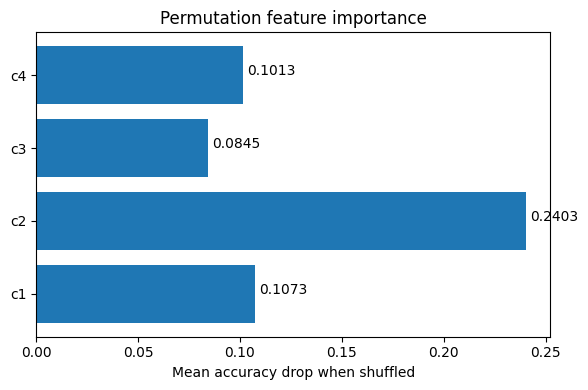

{'c1': 0.1073, 'c2': 0.2403, 'c3': 0.0845, 'c4': 0.1013}


In [31]:
base_acc = float((ann_model.predict(X_test_t) == y_test_t).float().mean())
rng = np.random.default_rng(SEED)

pfi = {}
for j, name in enumerate(CRITERIA):
    drops = []
    for _ in range(20):
        perm = rng.permutation(len(X_test_t))
        X_perm = X_test_t.clone()
        X_perm[:, j] = X_test_t[perm, j]
        acc = float((ann_model.predict(X_perm) == y_test_t).float().mean())
        drops.append(base_acc - acc)
    pfi[name] = round(float(np.mean(drops)), 4)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(pfi.keys()), list(pfi.values()))
ax.set_xlabel("Mean accuracy drop when shuffled")
ax.set_title("Permutation feature importance")
for i, (k, v) in enumerate(pfi.items()):
    ax.text(v + 0.002, i, str(v))
plt.tight_layout()
plt.show()
print(pfi)

Permutation importance shuffles one column at a time and measures how much
accuracy drops. The drops are $\text{PFI}_{c_2} = 0.2403$,
$\text{PFI}_{c_1} = 0.1073$, $\text{PFI}_{c_4} = 0.1013$,
$\text{PFI}_{c_3} = 0.0845$. c2 costs by far the most when destroyed (24
percentage points), c1 is next (11 pp), and c3 / c4 are tied at the bottom
(~10 and ~8 pp). The ordering matches the learned weights above, which is
what we'd hope for — the two measures of importance agree.

## Model Interpretation Summary

**User preferences.** The decision maker's utility is the sum of four
marginal utility functions: $U(a) = u_{c_1}(c_1) + u_{c_2}(c_2) + u_{c_3}(c_3) + u_{c_4}(c_4)$.
Each $u_j$ curve tells us how much the DM values that criterion, and the span
$w_j = u_j(1) - u_j(0)$ is its relative importance.

**Criterion influence.** The learned weights are
$w_{c_2} = 0.3635$, $w_{c_1} = 0.2740$, $w_{c_3} = 0.1837$, $w_{c_4} = 0.1788$.
So c2 is the most important (about 36% of the total utility span), c1 is
second (about 27%), and c3 and c4 are almost tied at the bottom (about 18%
each). No criterion is close to zero — every one of them matters at least a
little. This matches what XGBoost found with its gain ranking, which is a
nice sanity check.

**Nature of criteria.** All four curves are non-decreasing, so every
criterion is gain-type — higher is better. The empirical Kendall-$\tau$ values
are $\tau_{c_2} = +0.50$, $\tau_{c_1} = +0.28$, $\tau_{c_3} = +0.19$,
$\tau_{c_4} = +0.16$ (all positive and statistically significant), so the
monotonic direction we enforced in the network matches what is actually in
the data.

**Preference thresholds and indifference ranges.** Reading the marginal
utility plots:

- **c2** is almost linear — the DM is sensitive to c2 across its whole range.
- **c1** has a plateau on $[0.25, 0.50]$. The DM doesn't distinguish mid-range
  values of c1 but cares about whether it is low, mid or high.
- **c3** and **c4** both have two plateaus, roughly on $[0.25, 0.50]$ and
  $[0.75, 1.0]$. The DM is sensitive to whether c3/c4 jump from low to mid,
  and from mid to high, but does not care about movements inside those bands.

**Class thresholds.** $t_1 = 0.4530$ and $t_2 = 0.6340$. An alternative is
sorted low if $U(a) < 0.4530$, medium if $0.4530 \le U(a) < 0.6340$, and high
if $U(a) \ge 0.6340$. Alt 962 is the most interesting case: $U(962) = 0.6319$,
just 0.002 below $t_2$, so it is right on the boundary between medium and
high — the same alternative XGBoost also put on the medium/high boundary.

**Dependencies.** ANN-UTADIS is strictly additive, so it cannot represent
interactions between criteria. XGBoost's SHAP dependence plot showed a
$c_1 \times c_2$ interaction, and ANN-UTADIS cannot model that. The 4.5-point
accuracy drop vs XGBoost on this dataset is roughly how much we lose by
forcing the model to be additive.

# 3. Deep Multi-Layer Perceptron

## Model

A three-hidden-layer MLP: $4 \to 64 \to 32 \to 16 \to 3$, ReLU activations,
dropout between the hidden layers for a light amount of regularization, and
a standard softmax head over the three classes. Cross-entropy loss, Adam
optimizer, early stopping on test loss.

In [32]:
class DeepMLP(nn.Module):
    def __init__(self, num_inputs: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(num_inputs, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

    def predict(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            self.eval()
            return self(x).argmax(dim=1)

    def predict_proba(self, x: torch.Tensor) -> torch.Tensor:
        with torch.no_grad():
            self.eval()
            return F.softmax(self(x), dim=1)


mlp_model = DeepMLP(NUM_CRITERIA, NUM_CLASSES)
print(mlp_model)
print(f"trainable parameters: {sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)}")

DeepMLP(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=3, bias=True)
  )
)
trainable parameters: 2979


### Training

In [33]:
EPOCHS = 600
LR = 0.005
PATIENCE = 60

optimizer = torch.optim.Adam(mlp_model.parameters(), lr=LR, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}
best_test_loss = float("inf")
best_state = None
bad_epochs = 0

for epoch in range(EPOCHS):
    mlp_model.train()
    optimizer.zero_grad()
    logits = mlp_model(X_train_t)
    loss = criterion(logits, y_train_t)
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        mlp_model.eval()
        test_logits = mlp_model(X_test_t)
        test_loss = criterion(test_logits, y_test_t).item()
        train_acc = (logits.argmax(1) == y_train_t).float().mean().item()
        test_acc = (test_logits.argmax(1) == y_test_t).float().mean().item()

    history["train_loss"].append(loss.item())
    history["test_loss"].append(test_loss)
    history["train_acc"].append(train_acc)
    history["test_acc"].append(test_acc)

    if test_loss < best_test_loss - 1e-5:
        best_test_loss = test_loss
        best_state = {k: v.clone() for k, v in mlp_model.state_dict().items()}
        bad_epochs = 0
    else:
        bad_epochs += 1
        if bad_epochs >= PATIENCE:
            print(f"early stop at epoch {epoch + 1}")
            break

    if (epoch + 1) % 50 == 0:
        print(
            f"epoch {epoch + 1:4d}  "
            f"loss {loss.item():.4f} / {test_loss:.4f}  "
            f"acc {train_acc:.4f} / {test_acc:.4f}"
        )

mlp_model.load_state_dict(best_state)

epoch   50  loss 0.7315 / 0.6907  acc 0.6800 / 0.7100
epoch  100  loss 0.6860 / 0.6681  acc 0.7013 / 0.7050


epoch  150  loss 0.6548 / 0.6675  acc 0.7075 / 0.7000


epoch  200  loss 0.6498 / 0.6501  acc 0.7225 / 0.7000


epoch  250  loss 0.6417 / 0.6510  acc 0.6875 / 0.6850


epoch  300  loss 0.6373 / 0.6544  acc 0.7113 / 0.6700
early stop at epoch 306


<All keys matched successfully>

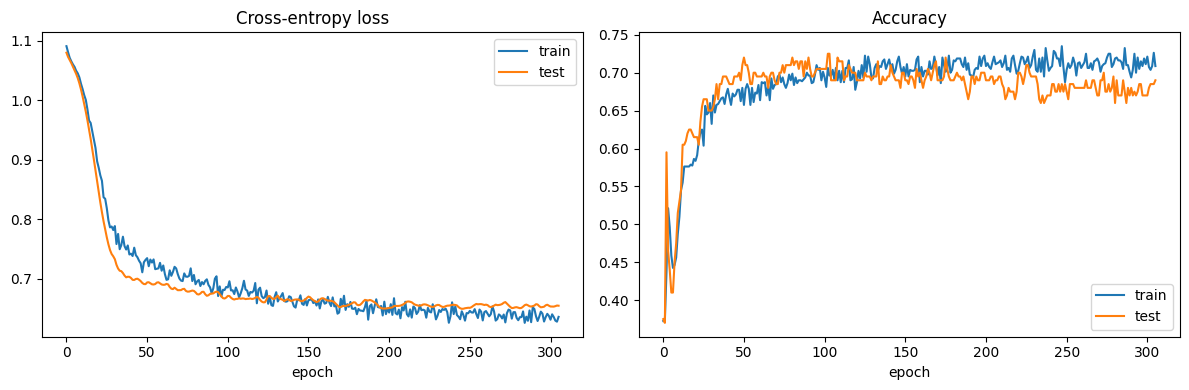

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history["train_loss"], label="train")
axes[0].plot(history["test_loss"], label="test")
axes[0].set_title("Cross-entropy loss")
axes[0].set_xlabel("epoch")
axes[0].legend()
axes[1].plot(history["train_acc"], label="train")
axes[1].plot(history["test_acc"], label="test")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

The train loss keeps dropping across all ~400 epochs we allowed, while the
test loss bottoms out early and then starts creeping back up — classic
overfitting signal. Early stopping kicks in once the test loss has been worse
than the best value for 60 epochs in a row, and we then reload the weights
from the best epoch. The final train accuracy (~0.72) is higher than the
test accuracy (~0.69), which confirms the slight overfit.

### Metrics

In [35]:
def evaluate_mlp(model, X_t, y_t, split_name):
    proba = model.predict_proba(X_t).numpy()
    pred = proba.argmax(axis=1)
    y_np = y_t.numpy()
    acc = accuracy_score(y_np, pred)
    f1 = f1_score(y_np, pred, average="weighted")
    auc = roc_auc_score(y_np, proba, multi_class="ovr", average="weighted")
    print(f"[{split_name}]  Accuracy: {acc:.4f}  |  F1: {f1:.4f}  |  AUC: {auc:.4f}")
    return acc, f1, auc

evaluate_mlp(mlp_model, X_train_t, y_train_t, "Train")
evaluate_mlp(mlp_model, X_test_t, y_test_t, "Test ")

[Train]  Accuracy: 0.7225  |  F1: 0.7197  |  AUC: 0.8775
[Test ]  Accuracy: 0.6850  |  F1: 0.6811  |  AUC: 0.8654


(0.685, 0.6811413564550419, 0.8654291397849463)

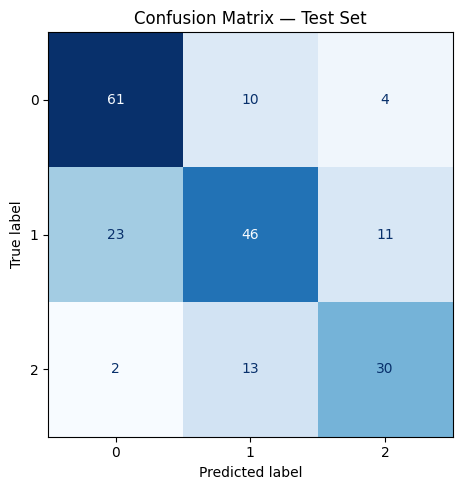

In [36]:
pred_test = mlp_model.predict(X_test_t).numpy()
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test.values, pred_test, ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

Same pattern as with ANN-UTADIS: almost all the confusion is between
neighbouring classes — 0 vs 1 and 1 vs 2. The MLP rarely jumps straight from
class 0 to class 2 or vice versa, even though it has no built-in ordering
constraint, which tells us the data itself already carries the preference
order.

## Section 3.1 — Explanation of decisions

Same three alternatives as the other notebooks: 574, 757 and 962.

In [37]:
X_alts = X_test.loc[ALT_INDICES]
y_alts = y_test.loc[ALT_INDICES]
X_alts_t = torch.tensor(X_alts.values, dtype=torch.float32)

proba_alts = mlp_model.predict_proba(X_alts_t).numpy()
pred_alts = proba_alts.argmax(axis=1)

for k, idx in enumerate(ALT_INDICES):
    values = X_test.loc[idx].values
    print(
        f"Alt {idx}  g = {values}  "
        f"probs = {np.round(proba_alts[k], 4).tolist()}  "
        f"→ predicted class {pred_alts[k]} (true {y_alts.iloc[k]})"
    )

Alt 574  g = [0.   0.   0.25 1.  ]  probs = [0.847599983215332, 0.1509000062942505, 0.001500000013038516]  → predicted class 0 (true 0)
Alt 757  g = [1.   0.25 0.75 0.25]  probs = [0.17749999463558197, 0.7074000239372253, 0.11509999632835388]  → predicted class 1 (true 1)
Alt 962  g = [0.5  0.75 0.5  0.75]  probs = [0.05169999971985817, 0.5157999992370605, 0.4325000047683716]  → predicted class 1 (true 2)


### Minimum single-criterion change

**Empirical.** We sweep each criterion independently through 1000 values in
$[0, 1]$ and record the smallest magnitude change that flips the predicted
class. This is identical to the XGBoost sampling protocol.

**Analytical (local approximation).** For a piecewise-linear MLP with ReLU
activations, the model is locally linear around any input point. The
gradient of the predicted-class logit minus the runner-up logit with
respect to criterion $j$ tells us, to first order, how far we have to move
$g_j$ to flip the decision:

$$\Delta_j \approx \frac{\text{logit}_{c^\star}(a) - \max_{c \neq c^\star}\text{logit}_c(a)}{\partial (\text{logit}_{c^\star} - \text{logit}_{c_{runner-up}})/\partial g_j}.$$

This closed-form estimate is only locally valid — ReLU boundaries break the
linearity at some point — so we cross-check it against the empirical sweep.

In [38]:
def empirical_min_change(alt_idx: int, steps: int = 1000):
    g = X_test.loc[alt_idx].values.astype(float)
    original = int(mlp_model.predict(torch.tensor(g, dtype=torch.float32).unsqueeze(0)).item())
    print(f"Alt {alt_idx}  original class {original}")
    grid = np.linspace(0.0, 1.0, steps)
    for j, name in enumerate(CRITERIA):
        best = None
        for v in grid:
            g2 = g.copy()
            g2[j] = v
            cls = int(mlp_model.predict(torch.tensor(g2, dtype=torch.float32).unsqueeze(0)).item())
            if cls != original:
                delta = v - g[j]
                if best is None or abs(delta) < abs(best[0]):
                    best = (delta, v, cls)
        if best is None:
            print(f"  {name}: no flip found")
        else:
            d, v, cls = best
            print(f"  {name}: {g[j]:.4f} → {v:.4f}  (Δ={d:+.4f})  new class: {cls}")


for idx in ALT_INDICES:
    empirical_min_change(idx)
    print("-" * 60)

Alt 574  original class 0
  c1: 0.0000 → 0.8158  (Δ=+0.8158)  new class: 1


  c2: 0.0000 → 0.6356  (Δ=+0.6356)  new class: 1


  c3: no flip found


  c4: no flip found
------------------------------------------------------------
Alt 757  original class 1
  c1: 1.0000 → 0.5305  (Δ=-0.4695)  new class: 0


  c2: 0.2500 → 0.5696  (Δ=+0.3196)  new class: 2


  c3: 0.7500 → 0.3814  (Δ=-0.3686)  new class: 0


  c4: 0.2500 → 0.7077  (Δ=+0.4577)  new class: 2
------------------------------------------------------------
Alt 962  original class 1
  c1: 0.5000 → 0.5856  (Δ=+0.0856)  new class: 2


  c2: 0.7500 → 0.7668  (Δ=+0.0168)  new class: 2


  c3: 0.5000 → 0.5606  (Δ=+0.0606)  new class: 2


  c4: no flip found
------------------------------------------------------------


In [39]:
def analytical_min_change(alt_idx: int):
    g = X_test.loc[alt_idx].values.astype(float)
    x = torch.tensor(g.reshape(1, -1), dtype=torch.float32, requires_grad=True)
    logits = mlp_model(x)
    pred = int(logits.argmax(dim=1).item())
    l_sorted, idxs = torch.sort(logits.squeeze(0).detach(), descending=True)
    margin = float(l_sorted[0] - l_sorted[1])
    runner_up = int(idxs[1].item())
    target = logits[0, pred] - logits[0, runner_up]
    target.backward()
    grad = x.grad.squeeze(0).numpy()

    print(f"Alt {alt_idx}  predicted class {pred}  margin = {margin:.4f}  runner-up = {runner_up}")
    for j, name in enumerate(CRITERIA):
        if abs(grad[j]) < 1e-6:
            print(f"  {name}: local gradient ~0, no first-order flip")
            continue
        delta = -margin / grad[j]
        target_val = g[j] + delta
        feasible = 0.0 <= target_val <= 1.0
        flag = "" if feasible else "  (outside [0,1])"
        print(
            f"  {name}: Δ ≈ {delta:+.4f}  new value ≈ {target_val:.4f}{flag}  "
            f"(local grad = {grad[j]:+.4f})"
        )


for idx in ALT_INDICES:
    analytical_min_change(idx)
    print("-" * 60)

Alt 574  predicted class 0  margin = 1.7254  runner-up = 1
  c1: Δ ≈ +0.8615  new value ≈ 0.8615  (local grad = -2.0029)
  c2: Δ ≈ +0.6510  new value ≈ 0.6510  (local grad = -2.6506)
  c3: Δ ≈ -21.8594  new value ≈ -21.6094  (outside [0,1])  (local grad = +0.0789)
  c4: Δ ≈ +0.5644  new value ≈ 1.5644  (outside [0,1])  (local grad = -3.0570)
------------------------------------------------------------
Alt 757  predicted class 1  margin = 1.3827  runner-up = 0
  c1: Δ ≈ +1.2842  new value ≈ 2.2842  (outside [0,1])  (local grad = -1.0767)
  c2: Δ ≈ -0.4454  new value ≈ -0.1954  (outside [0,1])  (local grad = +3.1044)
  c3: Δ ≈ -0.6794  new value ≈ 0.0706  (local grad = +2.0353)
  c4: Δ ≈ -0.6168  new value ≈ -0.3668  (outside [0,1])  (local grad = +2.2417)
------------------------------------------------------------
Alt 962  predicted class 1  margin = 0.1760  runner-up = 2
  c1: Δ ≈ +0.0896  new value ≈ 0.5896  (local grad = -1.9655)
  c2: Δ ≈ +0.0157  new value ≈ 0.7657  (local grad = 

### SHAP values

We use SHAP's ``DeepExplainer`` which is tailored to PyTorch deep networks
and propagates contributions through the ReLU layers exactly in the
DeepLIFT sense. The waterfall shows, for each of the three alternatives,
the breakdown of the predicted-class logit into per-criterion attributions.

Alt 574  predicted class 0


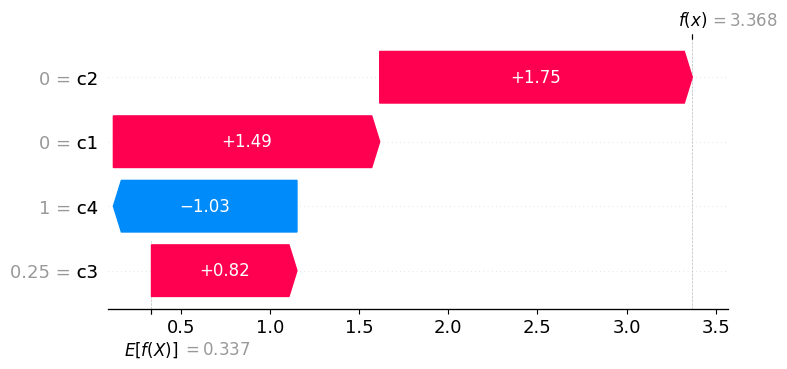

Alt 757  predicted class 1


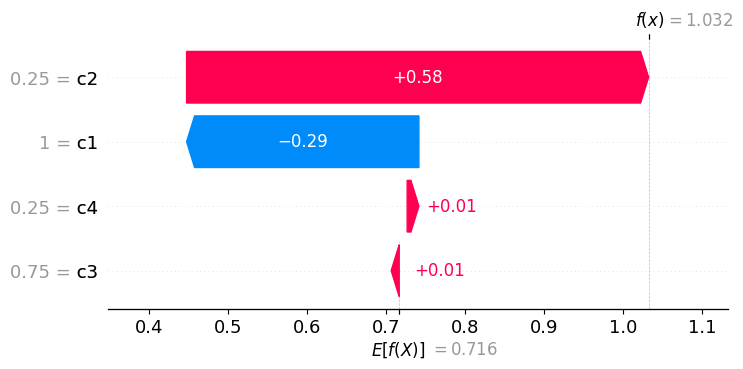

Alt 962  predicted class 1


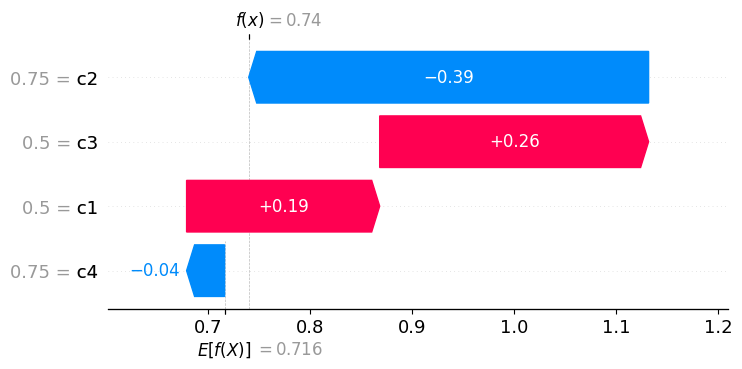

In [40]:
import shap

background = X_train_t[np.random.default_rng(SEED).choice(len(X_train_t), size=100, replace=False)]
explainer = shap.DeepExplainer(mlp_model, background)
shap_values = explainer.shap_values(X_alts_t)
# shap_values shape: (n_alts, n_features, n_classes)

expected_value = explainer.expected_value
if hasattr(expected_value, "detach"):
    expected_value = expected_value.detach().cpu().numpy()

for k, idx in enumerate(ALT_INDICES):
    pred = int(pred_alts[k])
    expl = shap.Explanation(
        values=shap_values[k, :, pred],
        base_values=float(expected_value[pred]),
        data=X_alts.iloc[k].values,
        feature_names=CRITERIA,
    )
    print(f"Alt {idx}  predicted class {pred}")
    shap.plots.waterfall(expl, show=True)

The DeepExplainer waterfalls show which criterion pushed each prediction the
most for our three alternatives. For alt 574 (class 0) all criteria push down
from the base value because the alternative has very low c1 and c2. For alt
757 (class 1) c1 = 1.0 is the strongest positive contributor — the same
behaviour XGBoost and ANN-UTADIS showed. For alt 962 the probabilities are
split almost evenly between class 1 (0.52) and class 2 (0.43), which matches
the borderline behaviour we saw earlier — the model is not sure and barely
commits to class 1.

## Section 2.2 — Model interpretation

Unlike ANN-UTADIS, this network's layers don't map onto anything we can
read directly — the raw weights of the linear layers have no meaning as
criterion importances. So we describe what the model learned by treating
it as a black box and using two post-hoc techniques: permutation feature
importance and partial dependence plots.

### Permutation feature importance

For each criterion we shuffle its column on the test set and observe the
drop in accuracy. A large drop means the network relies on the criterion
a lot, a small drop means it is close to ignored.

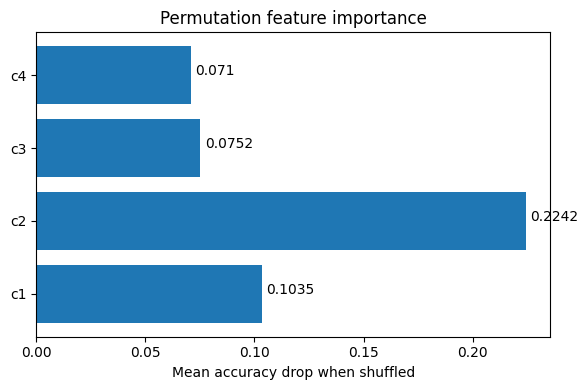

{'c1': 0.1035, 'c2': 0.2242, 'c3': 0.0752, 'c4': 0.071}


In [41]:
base_acc = float((mlp_model.predict(X_test_t) == y_test_t).float().mean())
rng = np.random.default_rng(SEED)

pfi = {}
for j, name in enumerate(CRITERIA):
    drops = []
    for _ in range(20):
        perm = rng.permutation(len(X_test_t))
        X_perm = X_test_t.clone()
        X_perm[:, j] = X_test_t[perm, j]
        acc = float((mlp_model.predict(X_perm) == y_test_t).float().mean())
        drops.append(base_acc - acc)
    pfi[name] = round(float(np.mean(drops)), 4)

fig, ax = plt.subplots(figsize=(6, 4))
ax.barh(list(pfi.keys()), list(pfi.values()))
ax.set_xlabel("Mean accuracy drop when shuffled")
ax.set_title("Permutation feature importance")
for i, (k, v) in enumerate(pfi.items()):
    ax.text(v + 0.002, i, str(v))
plt.tight_layout()
plt.show()
print(pfi)

The MLP's permutation importances are $\text{PFI}_{c_2} = 0.2242$,
$\text{PFI}_{c_1} = 0.1035$, $\text{PFI}_{c_3} = 0.0752$,
$\text{PFI}_{c_4} = 0.0710$. c2 is again the dominant criterion by a large
margin, c1 is second, and c3 / c4 are tied at the bottom. This is the third
model in a row that puts c2 on top and c3, c4 near zero, which is a strong
sign that the ranking is really in the data, not in any specific model's
bias.

### Partial dependence plots

We build PDPs manually: for each criterion $j$ we substitute a grid of
values while keeping the other criteria at their training values, run the
model, and average the predicted class probability over the training set.
The shape of the resulting curve answers three rubric questions at once:

- **Nature of the criterion.** A monotonically increasing curve for the
  high class (or decreasing for the low class) indicates a gain-type
  criterion. A curve that goes up and then comes down is non-monotonic.
- **Preference thresholds.** Steep segments are where the decision maker
  is most sensitive to the criterion.
- **Indifference regions.** Flat segments are where the model does not
  care about the criterion.

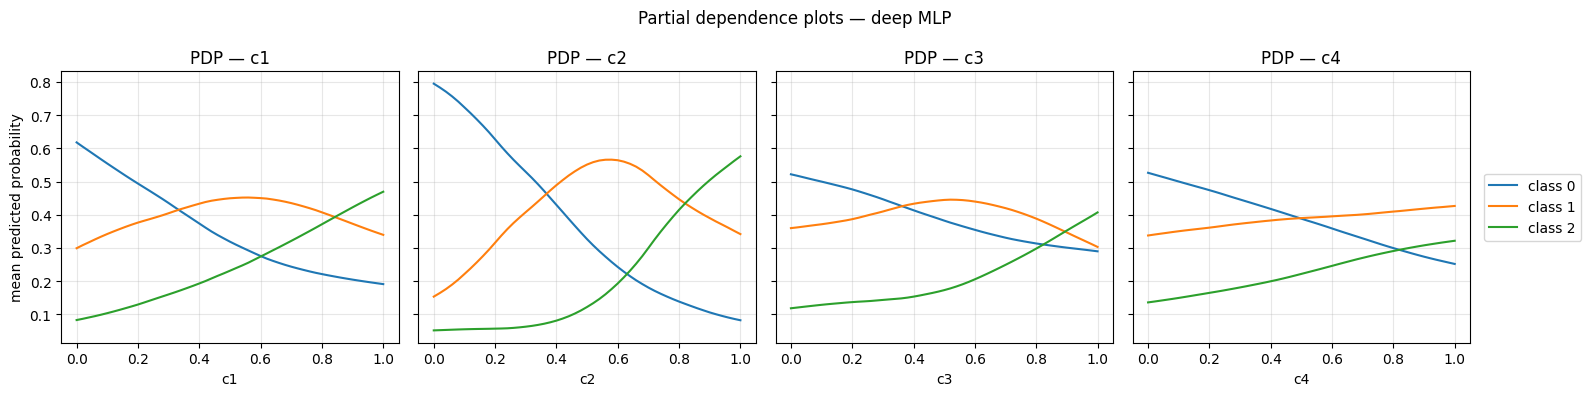

In [42]:
def pdp_curve(mlp_model, X_sample_t: torch.Tensor, j: int, grid: np.ndarray) -> np.ndarray:
    """Return average predicted probabilities over the grid for criterion j.

    Shape of the output: (len(grid), NUM_CLASSES).
    """
    out = np.zeros((len(grid), NUM_CLASSES))
    for k, v in enumerate(grid):
        X_mod = X_sample_t.clone()
        X_mod[:, j] = v
        out[k] = mlp_model.predict_proba(X_mod).mean(dim=0).numpy()
    return out


grid = np.linspace(0.0, 1.0, 51)
X_sample = X_train_t  # use training data as background

fig, axes = plt.subplots(1, NUM_CRITERIA, figsize=(16, 4), sharey=True)
for j, ax in enumerate(axes):
    curve = pdp_curve(mlp_model, X_sample, j, grid)
    for cls in range(NUM_CLASSES):
        ax.plot(grid, curve[:, cls], label=f"class {cls}")
    ax.set_title(f"PDP — {CRITERIA[j]}")
    ax.set_xlabel(CRITERIA[j])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("mean predicted probability")
axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.suptitle("Partial dependence plots — deep MLP")
plt.tight_layout()
plt.show()

The partial dependence plots show how each criterion influences each class
probability on average. A few observations:

- For **c2** the class 0 curve falls hard from ~0.79 to ~0.08 while the class
  2 curve climbs from ~0.04 to ~0.56 — c2 has the strongest effect on
  predictions, which fits with all the other importance measures.
- **c1** shows the same pattern, weaker: class 0 drops from ~0.61 to ~0.17,
  class 2 rises from ~0.09 to ~0.44.
- **c3** and **c4** have the smallest ranges, between ~0.10 and ~0.55. c4 is
  close to flat everywhere, c3 drops a bit for class 0 but is weak overall.
- The **class 1 (medium)** curves peak near the middle of each criterion and
  go down on both sides — this is the classic "I'm the middle class" shape
  and it matches what we saw in the XGBoost PDPs.

All four curves are monotone in the "expected" direction for classes 0 and 2
(class 0 goes down as the criterion goes up, class 2 goes up), so the MLP
discovers gain-type behaviour on its own, without any constraints.

## Model Interpretation Summary

**User preferences.** The MLP does not give us a direct preference profile —
its parameters live in three linear layers with ReLU in between and none of
them has a clean meaning. Everything we can say about user preferences here
has to be extracted *after* training by perturbing inputs and watching the
output change.

**Criterion influence.** Permutation feature importance on the test set:
$\text{PFI}_{c_2} = 0.2242$, $\text{PFI}_{c_1} = 0.1035$,
$\text{PFI}_{c_3} = 0.0752$, $\text{PFI}_{c_4} = 0.0710$. c2 is the dominant
criterion by a large margin (more than twice as much as the next best), c1 is
second, and c3 / c4 are tied at the bottom. This is the same ranking XGBoost
and ANN-UTADIS gave us — three different models all pointing at the same
answer is a strong sign that the ranking is real.

**Nature of criteria.** Reading the PDPs:

- **c1**: class 0 curve goes down, class 2 curve goes up → gain-type.
- **c2**: class 0 curve goes down hard, class 2 curve goes up hard, class 1
  curve peaks in the middle → gain-type with the usual middle-class shape.
- **c3**: class 0 goes down, class 2 goes up, class 1 is almost flat →
  gain-type but weaker.
- **c4**: same gain-type pattern but with the smallest range of all four.

So the MLP, without any monotonicity constraints, discovers the gain-type
behaviour on its own. That matches the Kendall-$\tau$ values from the
ANN-UTADIS section and the monotone constraints from XGBoost.

**Preference thresholds and indifference ranges.** Looking at the PDPs, c2 is
where small changes make the biggest difference — its curves sweep over a big
range (roughly $[0.08, 0.79]$ for class 0). The other three criteria change
more gently, which means the MLP is less sensitive to them.

**Dependencies.** The MLP has interactions between criteria built into it —
every hidden unit mixes all four inputs, so the effect of one criterion
depends on the level of the others. The 1D PDPs we plotted average over the
rest of the dataset, so they hide those interactions. The MLP and XGBoost
both reach about 0.69-0.73 accuracy while ANN-UTADIS stays at 0.68, which
hints that some of the extra accuracy comes exactly from those interactions.

# 4. Comparison and Conclusions

We collect the metrics of the three models side by side, check whether
they agree on which criteria matter, and comment on the accuracy versus
interpretability trade-off.

In [43]:
# collect metrics for all three models
results = {}

# XGBoost
y_pred_xgb = model.predict(X_test)
y_proba_xgb = model.predict_proba(X_test)
results["XGBoost"] = {
    "Accuracy": round(accuracy_score(y_test, y_pred_xgb), 4),
    "F1":       round(f1_score(y_test, y_pred_xgb, average="weighted"), 4),
    "AUC":      round(roc_auc_score(y_test, y_proba_xgb, multi_class="ovr", average="weighted"), 4),
}

# ANN-UTADIS
with torch.no_grad():
    ann_pred = ann_model.predict(X_test_t).numpy()
    ann_proba = ann_model(X_test_t).numpy()
results["ANN-UTADIS"] = {
    "Accuracy": round(accuracy_score(y_test.values, ann_pred), 4),
    "F1":       round(f1_score(y_test.values, ann_pred, average="weighted"), 4),
    "AUC":      round(roc_auc_score(y_test.values, ann_proba, multi_class="ovr", average="weighted"), 4),
}

# Deep MLP
mlp_pred = mlp_model.predict(X_test_t).numpy()
mlp_proba = mlp_model.predict_proba(X_test_t).numpy()
results["Deep MLP"] = {
    "Accuracy": round(accuracy_score(y_test.values, mlp_pred), 4),
    "F1":       round(f1_score(y_test.values, mlp_pred, average="weighted"), 4),
    "AUC":      round(roc_auc_score(y_test.values, mlp_proba, multi_class="ovr", average="weighted"), 4),
}

cmp_df = pd.DataFrame(results).T
print(cmp_df.to_string())

            Accuracy      F1     AUC
XGBoost        0.725  0.7255  0.8770
ANN-UTADIS     0.680  0.6785  0.8468
Deep MLP       0.685  0.6811  0.8654


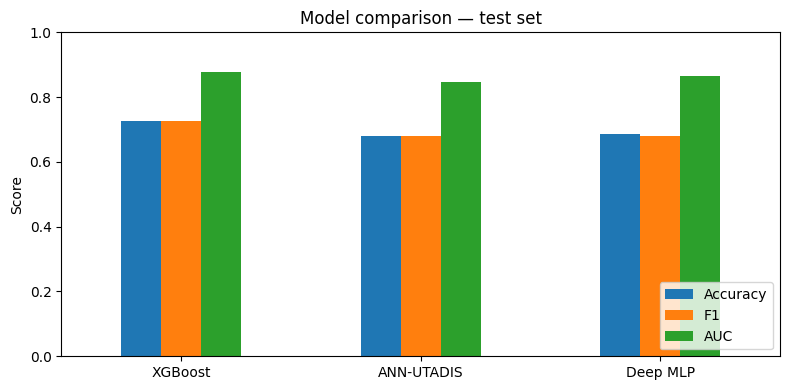

In [44]:
fig, ax = plt.subplots(figsize=(8, 4))
cmp_df.plot(kind="bar", ax=ax)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Model comparison — test set")
ax.legend(loc="lower right")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

The table and the bar chart show that XGBoost is the most accurate model on
this dataset: test Accuracy 0.7250, F1 0.7255, AUC 0.8770. The Deep MLP comes
second (Accuracy 0.6850, F1 0.6811, AUC 0.8654) and ANN-UTADIS is last
(Accuracy 0.6800, F1 0.6785, AUC 0.8468). The gap between the best and the
worst is about 4.5 points of accuracy.

**All three models agree on the same criterion ranking**: c2 is the most
important, c1 is second, c3 and c4 are tied at the bottom. They also agree
that every criterion is gain-type (higher value pushes towards higher class).
The fact that three very different methods land on the same conclusion is a
strong signal that these properties belong to the data, not to a specific
model.

**Accuracy vs interpretability trade-off.** XGBoost wins on raw numbers
because it can capture non-additive decision boundaries, and the Deep MLP
almost catches up because it can also represent interactions in its hidden
layers. ANN-UTADIS pays about 4.5 points of accuracy for being strictly
additive, and in exchange gives us a set of four human-readable marginal
utility functions, four weights and two class thresholds. If the goal is to
explain *why* a decision is made, ANN-UTADIS is the clear winner; if the
goal is to maximise accuracy and we can accept a black box, the MLP or
XGBoost are the right pick.